# Mirror Game: Pose Dynamics Analysis

Full pipeline: Motion capture → PCA → CRQA → Statistical analysis

![Illustration](mirror_game_fig1.png)

## 1. Setup & Data Loading

Load and prepare Mirror Game dataset with 3 experimental conditions:
- **b2b** (back-to-back): no visual feedback
- **uni** (unidirectional): one partner sees the other
- **f2f** (face-to-face): mutual visual feedback

In [6]:
import sys, os
from pathlib import Path

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parents[2] if (NB_DIR / "utils").exists() else NB_DIR.parents[1]
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from collections import defaultdict
from pose_dynamics.preprocessing import *
from pose_dynamics.geometry_utils import *
from pose_dynamics.io import *
from pose_dynamics.normalization import *
from pose_dynamics.rqa.crossRQA import crossRQA  
from pose_dynamics.rqa.multivariateRQA import multivariateRQA


# Adjust DATA_DIR and OUT_DIR and go
DATA_DIR = Path("/Users/cartersale/Documents/Pose_Dynamics/data/Mirror")
OUT_DIR  = NB_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Temporal Alignment

Resample to 30 Hz, synchronize, and trim dyadic sequences to equal length.

In [7]:
# Alignment options
ALLOW_ROTATION = True
ALLOW_SCALE    = False   
REF_IDX        = None    
N_COMPONENTS   = 14 
TARGET_RATE    = 30.0 

MG_FILES = sorted(DATA_DIR.glob("*.csv"))
if not MG_FILES:
    raise SystemExit(f"No CSVs found in {DATA_DIR}")

# Expect: P001_T3_P1_pose_3d.csv
import re
MG_RE = re.compile(r"^(P\d{3})_(T\d+)_((?:P1|P2))_pose_3d\.csv$", re.IGNORECASE)

index = defaultdict(dict)  # {(pair,trial): {'P1': Path, 'P2': Path}}
bad = []

for f in MG_FILES:
    m = MG_RE.match(f.name)
    if not m:
        bad.append(f.name)
        continue
    pair_id, trial_id, party = m.group(1).upper(), m.group(2).upper(), m.group(3).upper()
    index[(pair_id, trial_id)][party] = f

print(f"Trials indexed: {len(index)} | Unparsed: {len(bad)}")
if bad[:5]: print("Unparsed sample:", bad[:5])

trial_groups = {}   # {(pair,trial): {'P1': (fname, df, cols), 'P2': (...)}}

for (pair_id, trial_id), parties in index.items():
    if "P1" not in parties or "P2" not in parties:
        continue

    f1, f2 = parties["P1"], parties["P2"]
    df1_raw = pd.read_csv(f1)
    df2_raw = pd.read_csv(f2)

    # 30 Hz resample using dt_ms
    df1 = resample(df1_raw, target_rate=TARGET_RATE)
    df2 = resample(df2_raw, target_rate=TARGET_RATE)

    # overlap + truncate to equal length
    df1_aligned, df2_aligned = align_pair(df1, df2)

    # xyz triplets present in each stream
    cols1 = order_xyz_triplets(df1_aligned.columns)
    cols2 = order_xyz_triplets(df2_aligned.columns)
    if not cols1 or not cols2:
        continue

    trial_groups[(pair_id, trial_id)] = {
        "P1": (f1.name, df1_aligned, cols1),
        "P2": (f2.name, df2_aligned, cols2),
    }

len(trial_groups)



Trials indexed: 216 | Unparsed: 2
Unparsed sample: ['rename_files.csv', 'rename_log.csv']


216

## 3. Spatial Alignment (Procrustes)

Center poses and build global template. Align all trials to canonical reference using Procrustes to remove position, scale, and orientation differences.

In [8]:
# Stage 1: center/canonicalise per trial to build a global template
trials = []     # list of (fname, df, cols)
centred = []    # list of flattened arrays (T, n_points*3)

for key, parties in trial_groups.items():
    for party in ("P1", "P2"):
        fname, df, cols = parties[party]
        trials.append((fname, df, cols))
        arr_flat, _meta = align_keypoints_3d(
            df, expected_cols=cols, ref_idx=REF_IDX,
            template=None, use_procrustes=False,  # first pass: centre only
            allow_rotation=False, allow_scale=False
        )
        centred.append(arr_flat)

if not trials:
    raise SystemExit("No usable trials after preprocessing.")

n_points = len(trials[0][2]) // 3

# Build a global template from the centred sequences
template = build_template_with_canonicalisation(centred, n_points)
template.shape  # (n_points, 3)

(38, 3)

## 4. Dimensionality Reduction (PCA)

Extract Principal Movements (PMs) from 3D motion data. Each PM captures a fundamental mode of variation (e.g., swaying, reaching, rotation).

In [9]:
# Canonicalise once per frame against the global template
all_aligned = []  # list of (T, n_points*3)

for (fname, df, cols), arr_flat in zip(trials, centred):
    arr_frames = arr_flat.reshape(-1, n_points, 3)
    canon_seq  = canonicalise_trial(arr_frames, template)  # shape: (T, n_points, 3)
    all_aligned.append(canon_seq.reshape(canon_seq.shape[0], -1))  # flatten per frame

# Stack and PCA
X = np.vstack(all_aligned)
X_mean = X.mean(0, keepdims=True)
X_mc   = X - X_mean

k = min(N_COMPONENTS, X_mc.shape[1])
pca = PCA(n_components=k).fit(X_mc)
evr = pca.explained_variance_ratio_ * 100.0
print("Explained variance:", ", ".join(f"PC{i+1}:{v:.2f}%" for i,v in enumerate(evr)))

# Save PCA parts
np.save(OUT_DIR / "pca_components.npy", pca.components_)
np.save(OUT_DIR / "pca_mean.npy",       X_mean.squeeze())
with open(OUT_DIR / "pca_explained_variance.txt", "w") as f:
    for i, v in enumerate(evr, 1):
        f.write(f"PC{i}: {v:.4f}%\n")

# Keep mapping from trial index -> (pair_trial, party)
pair_trials = []   # parallel to trials list
for (pair_id, trial_id), parties in trial_groups.items():
    for party in ("P1", "P2"):
        pair_trials.append((f"{pair_id}_{trial_id}", party))

pc_scores = [pca.transform(arr) for arr in all_aligned]  # list of (T, k)

# Save per-trial PC scores for reproducibility
OUT_PC = OUT_DIR / "pc_scores"
OUT_PC.mkdir(parents=True, exist_ok=True)

for (pair_trial, party), scores in zip(pair_trials, pc_scores):
    np.save(OUT_PC / f"{pair_trial}_{party}_pc.npy", scores)


Explained variance: PC1:28.47%, PC2:15.47%, PC3:10.58%, PC4:9.89%, PC5:6.34%, PC6:5.64%, PC7:4.75%, PC8:3.57%, PC9:2.57%, PC10:2.30%, PC11:2.01%, PC12:1.80%, PC13:1.40%, PC14:0.69%


/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning:

divide by zero encountered in matmul

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning:

overflow encountered in matmul

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning:

invalid value encountered in matmul

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

divide by zero encountered in matmul

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

overflow encountered in matmul

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

invalid value encountered in matmul

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_base.py

## 5. Cross-Recurrence Quantification (CRQA)

Quantify dyadic coordination using CRQA metrics:
- **%REC**: Recurrence rate (how often similar states occur)
- **%DET**: Determinism (structure/predictability)
- **Entropy**, **Laminarity**, **Trapping Time**: Pattern complexity and persistence

In [ ]:
from pose_dynamics.pc_rqa_utils import run_pc_rqa_analysis, merge_pc_rqa_with_conditions

# RQA params
RQA_PARAMS = dict(
    eDim=4,          # embedding dimension
    tLag=10,         # time lag
    radius=0.20,     # recurrence threshold
    minl=2,          # minimum diagonal line length
    rescaleNorm=1,   # 1: mean-distance rescale
    norm=2,          # z-score normalization
)

# Run CRQA on PCs
print("Running Cross-RQA on Principal Components...")
df_crqa = run_pc_rqa_analysis(
    pc_scores=pc_scores,
    pair_trials=pair_trials,
    params=RQA_PARAMS,
    verbose=True
)

# Save results
df_crqa.to_csv(OUT_DIR / "crqa_by_pc.csv", index=False)
print(f"\nSaved {len(df_crqa)} CRQA results")

# Merge with conditions
try:
    merged = merge_pc_rqa_with_conditions(
        df_crqa,
        conditions_csv="Mirror_Game_Conditions.csv",
        verbose=True
    )
    merged.to_csv("CRQA_Stats_with_Conditions.csv", index=False)
    print("Saved merged results to CRQA_Stats_with_Conditions.csv")
    display(merged.head())
except FileNotFoundError:
    print("Conditions file not found. Skipping merge.")
    merged = df_crqa
    display(df_crqa.head())

## 6. Multivariate Recurrence

### 6a. Multivariate RQA on Keypoints

Run mdRQA directly on aligned keypoints (instead of PCs) with flexible options:

**Keypoint modes**: all (114D) | xy_only (76D) | subset (custom)  
**RQA modes**: auto (individual) | cross (dyadic) | joint (combined)

### 6b. Multivariate Recurrence on PCs

#### Setup

In [ ]:
from pathlib import Path
import numpy as np, pandas as pd
from pose_dynamics.rqa.multivariateRQA import multivariateRQA

OUT_DIR = OUT_DIR  # you already defined this earlier
K_MDRQA = 8        # try [3,5,8,12] for sensitivity

# MdRQA expects string norms (e.g., 'zscore'), not numeric codes
BASE_PARAMS = dict(RQA_PARAMS)
BASE_PARAMS.update({
    'norm': 'zscore',
    'rescaleNorm': 1,
    'radius': 0.30,   # tune to reach ~2–5% REC for chosen K; then keep fixed for that K
    'minl': 2,
    'tw': 1,
    'plotMode': None,
    'pointSize': 1,
    'showMetrics': False,
    'saveFig': False,
    'doStatsFile': False,
})

def parse_pair_trial(df, col='pair_trial'):
    pt = df[col].str.extract(r"P(\d+)_T(\d+)")
    pt.columns = ["Pair","Trial"]
    df["Pair"]  = pt["Pair"].astype(int)
    df["Trial"] = pt["Trial"].astype(int)
    return df

def add_conditions(df, cond_long):
    # cond_long has columns: Pair, Trial, Condition, Leader
    out = df.merge(cond_long, on=["Pair","Trial"], how="left")
    return out


NameError: name 'RQA_PARAMS' is not defined

#### MdRQA (Auto) - per participant
How structured/stable is each person’s own K-D movement?

In [ ]:
MDRQA_PARAMS = dict(BASE_PARAMS)

rows = []
for pair_trial, pmap in pair_to_indices.items():
    if 'P1' not in pmap or 'P2' not in pmap: 
        continue
    i1, i2 = pmap['P1'], pmap['P2']
    pcs1, pcs2 = pc_scores[i1], pc_scores[i2]
    T = min(pcs1.shape[0], pcs2.shape[0])

    for party, pcs in (('P1', pcs1), ('P2', pcs2)):
        X = pcs[:T, :K_MDRQA]    # (T, K)
        td, rs, mats, err = multivariateRQA(X, MDRQA_PARAMS, mode='auto')
        row = {'pair_trial': pair_trial, 'party': party, 'K': K_MDRQA, 'error': int(err)}
        if err == 0:
            row.update({k: float(v) for k, v in rs.items()})
            row['SD_mean']  = float(np.std(X, axis=0).mean())
            row['Vel_mean'] = float(np.mean(np.abs(np.diff(X, axis=0)), axis=0).mean())
        rows.append(row)

df_mdrqa = pd.DataFrame(rows)
df_mdrqa = parse_pair_trial(df_mdrqa, 'pair_trial')
df_mdrqa = add_conditions(df_mdrqa, cond_long)
df_mdrqa['Role'] = np.where(df_mdrqa['party'] == df_mdrqa['Leader'], 'Leader', 'Follower')

out_auto = OUT_DIR / f"mdrqa_auto_top{K_MDRQA}_pcs_with_conditions.csv"
df_mdrqa.to_csv(out_auto, index=False)
print(f"Saved {out_auto}")


Saved results/mdrqa_auto_top8_pcs_with_conditions.csv


#### MdCRQA (Cross) — P1 vs P2 in K-D PC space
How coupled/synchronized are the two participants?

In [ ]:
MDCRQA_PARAMS = dict(BASE_PARAMS)

rows = []
for pair_trial, pmap in pair_to_indices.items():
    if 'P1' not in pmap or 'P2' not in pmap: 
        continue
    i1, i2 = pmap['P1'], pmap['P2']
    pcs1, pcs2 = pc_scores[i1], pc_scores[i2]
    T = min(pcs1.shape[0], pcs2.shape[0])
    X = pcs1[:T, :K_MDRQA]   # P1 (T,K)
    Y = pcs2[:T, :K_MDRQA]   # P2 (T,K)

    td, rs, mats, err = multivariateRQA([X, Y], MDCRQA_PARAMS, mode='cross')
    row = {'pair_trial': pair_trial, 'K': K_MDRQA, 'error': int(err)}
    if err == 0:
        row.update({k: float(v) for k, v in rs.items()})
        # simple linear companions
        row['Leader_SD']    = float(np.std(X, axis=0).mean())
        row['Follower_SD']  = float(np.std(Y, axis=0).mean())
        row['Leader_Vel']   = float(np.mean(np.abs(np.diff(X, axis=0)), axis=0).mean())
        row['Follower_Vel'] = float(np.mean(np.abs(np.diff(Y, axis=0)), axis=0).mean())
    rows.append(row)

df_mdcrqa = pd.DataFrame(rows)
df_mdcrqa = parse_pair_trial(df_mdcrqa, 'pair_trial')
df_mdcrqa = add_conditions(df_mdcrqa, cond_long)

out_cross = OUT_DIR / f"mdcrqa_cross_top{K_MDRQA}_pcs_with_conditions.csv"
df_mdcrqa.to_csv(out_cross, index=False)
print(f"Saved {out_cross}")


Saved results/mdcrqa_cross_top8_pcs_with_conditions.csv


#### Joint-space MdRQA (AUTO on [P1|P2] concatenated)
How structured is the dyad as a single system?

In [ ]:
JOINT_PARAMS = dict(BASE_PARAMS)

rows = []
for pair_trial, pmap in pair_to_indices.items():
    if 'P1' not in pmap or 'P2' not in pmap: 
        continue
    i1, i2 = pmap['P1'], pmap['P2']
    pcs1, pcs2 = pc_scores[i1], pc_scores[i2]
    T = min(pcs1.shape[0], pcs2.shape[0])
    X1 = pcs1[:T, :K_MDRQA]
    X2 = pcs2[:T, :K_MDRQA]
    Z  = np.concatenate([X1, X2], axis=1)     # (T, 2K)

    td, rs, mats, err = multivariateRQA(Z, JOINT_PARAMS, mode='auto')
    row = {'pair_trial': pair_trial, 'K_total': Z.shape[1], 'error': int(err)}
    if err == 0:
        row.update({k: float(v) for k, v in rs.items()})
        row['SD_mean']  = float(np.std(Z, axis=0).mean())
        row['Vel_mean'] = float(np.mean(np.abs(np.diff(Z, axis=0)), axis=0).mean())
    rows.append(row)

df_joint = pd.DataFrame(rows)
df_joint = parse_pair_trial(df_joint, 'pair_trial')
df_joint = add_conditions(df_joint, cond_long)

out_joint = OUT_DIR / f"mdrqa_jointspace_{2*K_MDRQA}d_with_conditions.csv"
df_joint.to_csv(out_joint, index=False)
print(f"Saved {out_joint}")


Saved results/mdrqa_jointspace_16d_with_conditions.csv


## 7. Statistical Analysis

Repeated-measures ANOVAs and post-hoc tests for each PC and CRQA metric across conditions.

### Linear

#### Aggregated Components

In [13]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from statsmodels.stats.anova import AnovaRM

# Import stats utilities
sys.path.insert(0, str(Path.cwd().parent / "src"))
from pose_dynamics import stats_utils

# Setup
OUT_DIR = Path("results")
STATS_DIR = OUT_DIR / "statistics"
STATS_DIR.mkdir(parents=True, exist_ok=True)

# Load data
print("="*80)
print("LINEAR METRICS: Condition × Role Effects")
print("="*80)

df_crqa = pd.read_csv(OUT_DIR / "CRQA_Stats_with_Conditions.csv")
print(f"\nData: {len(df_crqa)} rows, {df_crqa['Pair'].nunique()} pairs")

# Create Leader/Follower columns
df_crqa['Leader_SD'] = df_crqa.apply(
    lambda r: r['P1_SD'] if r['Leader'] == 'P1' else r['P2_SD'], axis=1
)
df_crqa['Follower_SD'] = df_crqa.apply(
    lambda r: r['P2_SD'] if r['Leader'] == 'P1' else r['P1_SD'], axis=1
)
df_crqa['Leader_Vel'] = df_crqa.apply(
    lambda r: r['P1_mean_velocity'] if r['Leader'] == 'P1' else r['P2_mean_velocity'], axis=1
)
df_crqa['Follower_Vel'] = df_crqa.apply(
    lambda r: r['P2_mean_velocity'] if r['Leader'] == 'P1' else r['P1_mean_velocity'], axis=1
)

# Aggregate across PCs and trials
linear_metrics = ['Leader_SD', 'Follower_SD', 'Leader_Vel', 'Follower_Vel']
df_linear = stats_utils.aggregate_across_pcs(
    df_crqa,
    groupby_cols=['Pair', 'Trial', 'Condition', 'Leader'],
    metric_cols=linear_metrics
)
df_linear = df_linear.groupby(['Pair', 'Condition'], as_index=False)[linear_metrics].mean()

print(f"After aggregation: {len(df_linear)} rows\n")

# ============================================================================
# Test 1: Variability (SD)
# ============================================================================

print("--- VARIABILITY (SD) ---")
df_sd_long = stats_utils.prepare_leader_follower_data(
    df_linear, metric_prefix='SD', id_cols=['Condition', 'Pair']
)

try:
    aovrm = AnovaRM(df_sd_long, depvar='Value', subject='Pair', within=['Condition', 'Role'])
    res_sd = aovrm.fit()
    
    anova_table_sd = res_sd.anova_table.copy()
    
    # Calculate partial eta squared
    for effect in anova_table_sd.index:
        ss_effect = anova_table_sd.loc[effect, 'F Value'] * anova_table_sd.loc[effect, 'Num DF']
        ss_error = anova_table_sd.loc[effect, 'Den DF']
        anova_table_sd.loc[effect, 'partial_eta_sq'] = ss_effect / (ss_effect + ss_error)
    
    print("\n2-way RM-ANOVA: SD ~ Condition × Role")
    print(anova_table_sd)
    
    print("\nFormatted Results:")
    for effect in anova_table_sd.index:
        row = anova_table_sd.loc[effect]
        f_val = row['F Value']
        df_num = int(row['Num DF'])
        df_den = int(row['Den DF'])
        p_val = row['Pr > F']
        eta_sq = row['partial_eta_sq']
        
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
        
        print(f"  {effect:20s}: F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
    
    # Save
    anova_table_sd.to_csv(STATS_DIR / "linear_SD_anova.csv")
    
    # Post-hoc if Condition significant
    if anova_table_sd.loc['Condition', 'Pr > F'] < 0.05:
        print("\n  Condition effect significant! Post-hoc tests:")
        posthoc_sd = stats_utils.bonferroni_pairwise(df_sd_long, 'Value', 'Condition')
        for _, r in posthoc_sd.iterrows():
            if r['Significant']:
                print(f"    {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
        posthoc_sd.to_csv(STATS_DIR / "linear_SD_posthoc.csv", index=False)
    
    print("\n✓ SD analysis complete")
    
except Exception as e:
    print(f"\n❌ SD ANOVA failed: {e}")
    import traceback
    traceback.print_exc()

# ============================================================================
# Test 2: Mean Velocity
# ============================================================================

print("\n" + "="*80)
print("--- MEAN VELOCITY ---")
df_vel_long = stats_utils.prepare_leader_follower_data(
    df_linear, metric_prefix='Vel', id_cols=['Condition', 'Pair']
)

try:
    aovrm = AnovaRM(df_vel_long, depvar='Value', subject='Pair', within=['Condition', 'Role'])
    res_vel = aovrm.fit()
    
    anova_table_vel = res_vel.anova_table.copy()
    
    # Calculate partial eta squared
    for effect in anova_table_vel.index:
        ss_effect = anova_table_vel.loc[effect, 'F Value'] * anova_table_vel.loc[effect, 'Num DF']
        ss_error = anova_table_vel.loc[effect, 'Den DF']
        anova_table_vel.loc[effect, 'partial_eta_sq'] = ss_effect / (ss_effect + ss_error)
    
    print("\n2-way RM-ANOVA: Velocity ~ Condition × Role")
    print(anova_table_vel)
    
    print("\nFormatted Results:")
    for effect in anova_table_vel.index:
        row = anova_table_vel.loc[effect]
        f_val = row['F Value']
        df_num = int(row['Num DF'])
        df_den = int(row['Den DF'])
        p_val = row['Pr > F']
        eta_sq = row['partial_eta_sq']
        
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
        
        print(f"  {effect:20s}: F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
    
    # Save
    anova_table_vel.to_csv(STATS_DIR / "linear_Velocity_anova.csv")
    
    # Post-hoc if Condition significant
    if anova_table_vel.loc['Condition', 'Pr > F'] < 0.05:
        print("\n  Condition effect significant! Post-hoc tests:")
        posthoc_vel = stats_utils.bonferroni_pairwise(df_vel_long, 'Value', 'Condition')
        for _, r in posthoc_vel.iterrows():
            if r['Significant']:
                print(f"    {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
        posthoc_vel.to_csv(STATS_DIR / "linear_Velocity_posthoc.csv", index=False)
    
    print("\n✓ Velocity analysis complete")
    
    
except Exception as e:
    print(f"\n❌ Velocity ANOVA failed: {e}")
    import traceback
    traceback.print_exc()

# ============================================================================
# Simple Effects for Significant Condition × Role Interaction (Velocity)
# ============================================================================

print("\n" + "="*80)
print("SIMPLE-EFFECTS ANALYSIS (Velocity Interaction)")
print("="*80)

try:
    # ------------------------------------------------------------
    # 1. Compute leader–follower difference within each Pair/Condition
    # ------------------------------------------------------------
    df_delta = df_linear.copy()
    df_delta["Delta_Vel"] = df_delta["Leader_Vel"] - df_delta["Follower_Vel"]

    # pivot so we can do paired comparisons
    df_pivot = df_delta.pivot(index="Pair", columns="Condition", values="Delta_Vel")

    # Ensure correct condition order (if names differ, update here)
    conds = list(df_pivot.columns)

    print("\nLeader–Follower Velocity Differences (per Pair):")
    print(df_pivot.round(3))

    # ------------------------------------------------------------
    # 2. Simple effects: Leader vs Follower within each condition
    # ------------------------------------------------------------
    print("\n--- Simple Effects: Role difference within each Condition ---")
    simple_role_tests = []

    for cond in conds:
        # Extract leader/follower for this condition (already aggregated)
        df_cond = df_vel_long[df_vel_long["Condition"] == cond]

        # leader vs follower
        leader_vals = df_cond[df_cond["Role"] == "Leader"]["Value"]
        follower_vals = df_cond[df_cond["Role"] == "Follower"]["Value"]

        # Paired t-test
        from scipy.stats import ttest_rel
        t_stat, p_val = ttest_rel(leader_vals, follower_vals)

        # Cohen’s d for paired
        d = (leader_vals.mean() - follower_vals.mean()) / \
            (df_cond.groupby("Pair")["Value"].diff().dropna().std())

        simple_role_tests.append((cond, t_stat, p_val, d))
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"{cond}: t = {t_stat:.2f}, p = {p_val:.3f}, d = {d:.2f} {sig}")

    # ------------------------------------------------------------
    # 3. Compare deltas between conditions: Δ_condition comparisons
    # ------------------------------------------------------------
    print("\n--- Comparisons of Leader–Follower Gap Across Conditions ---")
    from itertools import combinations
    paired_delta_tests = []

    for c1, c2 in combinations(conds, 2):
        t_stat, p_val = ttest_rel(df_pivot[c1], df_pivot[c2])

        # Cohen’s d for paired deltas
        d = (df_pivot[c1].mean() - df_pivot[c2].mean()) / \
            (df_pivot[c1] - df_pivot[c2]).std()

        paired_delta_tests.append((c1, c2, t_stat, p_val, d))
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"{c1} vs {c2}: t = {t_stat:.2f}, p = {p_val:.3f}, d = {d:.2f} {sig}")

    print("\n✓ Simple-effects analysis complete\n")

except Exception as e:
    print(f"\n❌ Simple-effects analysis failed: {e}")
    import traceback
    traceback.print_exc()

# ============================================================================
# Summary
# ============================================================================

print("\n" + "="*80)
print("LINEAR METRICS SUMMARY")
print("="*80)

try:
    print("\nVariability (SD):")
    for effect in anova_table_sd.index:
        p = anova_table_sd.loc[effect, 'Pr > F']
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"  {effect:20s}: {sig}")
except:
    print("\nVariability (SD): Failed")

try:
    print("\nMean Velocity:")
    for effect in anova_table_vel.index:
        p = anova_table_vel.loc[effect, 'Pr > F']
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"  {effect:20s}: {sig}")
except:
    print("\nMean Velocity: Failed")

print("\n" + "="*80)

LINEAR METRICS: Condition × Role Effects

Data: 3024 rows, 18 pairs
After aggregation: 54 rows

--- VARIABILITY (SD) ---

2-way RM-ANOVA: SD ~ Condition × Role
                  F Value  Num DF  Den DF        Pr > F  partial_eta_sq
Condition       14.632639     2.0    34.0  2.602133e-05        0.462580
Role            68.036123     1.0    17.0  2.401031e-07        0.800085
Condition:Role   2.837633     2.0    34.0  7.249435e-02        0.143043

Formatted Results:
  Condition           : F(2, 34) = 14.63, p < .001, η²p = 0.463 ***
  Role                : F(1, 17) = 68.04, p < .001, η²p = 0.800 ***
  Condition:Role      : F(2, 34) = 2.84, p = 0.072, η²p = 0.143 ns

  Condition effect significant! Post-hoc tests:
    b2b vs f2f: p=0.000, d=-0.67
    b2b vs uni: p=0.002, d=-0.44
    f2f vs uni: p=0.007, d=0.22

✓ SD analysis complete

--- MEAN VELOCITY ---

2-way RM-ANOVA: Velocity ~ Condition × Role
                  F Value  Num DF  Den DF    Pr > F  partial_eta_sq
Condition       18.906

#### Per-Component

In [9]:
# =============================================================================
# PER-COMPONENT ANALYSIS: SD & Velocity
# =============================================================================

print("\n" + "="*80)
print("PER-COMPONENT ANALYSIS: SD & Velocity")
print("="*80)

# Identify all PCs in the dataset
pcs = sorted(df_crqa["PC"].unique())
print(f"Detected {len(pcs)} PCs:", pcs)

per_pc_results_sd = []
per_pc_results_vel = []

for pc in pcs:
    print(f"\n--- PC {pc}: Running SD and Velocity ANOVAs ---")

    # -----------------------------
    # 1. Subset to this component
    # -----------------------------
    df_pc = df_crqa[df_crqa["PC"] == pc].copy()

    # -----------------------------
    # 2. Compute Leader/Follower vars
    # -----------------------------
    df_pc['Leader_SD'] = df_pc.apply(
        lambda r: r['P1_SD'] if r['Leader'] == 'P1' else r['P2_SD'], axis=1
    )
    df_pc['Follower_SD'] = df_pc.apply(
        lambda r: r['P2_SD'] if r['Leader'] == 'P1' else r['P1_SD'], axis=1
    )
    df_pc['Leader_Vel'] = df_pc.apply(
        lambda r: r['P1_mean_velocity'] if r['Leader'] == 'P1' else r['P2_mean_velocity'], axis=1
    )
    df_pc['Follower_Vel'] = df_pc.apply(
        lambda r: r['P2_mean_velocity'] if r['Leader'] == 'P1' else r['P1_mean_velocity'], axis=1
    )

    # -----------------------------
    # 3. Aggregate within trial
    # -----------------------------
    df_pc_lin = df_pc.groupby(
        ["Pair", "Trial", "Condition", "Leader"],
        as_index=False
    )[["Leader_SD", "Follower_SD", "Leader_Vel", "Follower_Vel"]].mean()

    # -----------------------------
    # 4. Aggregate across trials → Pair × Condition
    # -----------------------------
    df_pc_lin = df_pc_lin.groupby(
        ["Pair", "Condition"], as_index=False
    )[["Leader_SD", "Follower_SD", "Leader_Vel", "Follower_Vel"]].mean()

    # -----------------------------
    # 5. SD Analysis
    # -----------------------------
    df_sd_long = stats_utils.prepare_leader_follower_data(
        df_pc_lin, metric_prefix='SD', id_cols=['Condition', 'Pair']
    )

    try:
        aov_sd = AnovaRM(df_sd_long, depvar='Value',
                         subject='Pair', within=['Condition', 'Role']).fit()

        tbl = aov_sd.anova_table.copy()
        # Partial eta squared
        for eff in tbl.index:
            ss_eff = tbl.loc[eff, 'F Value'] * tbl.loc[eff, 'Num DF']
            ss_err = tbl.loc[eff, 'Den DF']
            tbl.loc[eff, 'eta_p'] = ss_eff / (ss_eff + ss_err)

        per_pc_results_sd.append({
            "PC": pc,
            "anova": tbl
        })

    except Exception as e:
        print(f"SD ANOVA failed for PC {pc}: {e}")
        per_pc_results_sd.append({
            "PC": pc,
            "anova": None,
            "error": str(e)
        })

    # -----------------------------
    # 6. Velocity Analysis
    # -----------------------------
    df_vel_long = stats_utils.prepare_leader_follower_data(
        df_pc_lin, metric_prefix='Vel', id_cols=['Condition', 'Pair']
    )

    try:
        aov_vel = AnovaRM(df_vel_long, depvar='Value',
                          subject='Pair', within=['Condition', 'Role']).fit()

        tbl = aov_vel.anova_table.copy()
        for eff in tbl.index:
            ss_eff = tbl.loc[eff, 'F Value'] * tbl.loc[eff, 'Num DF']
            ss_err = tbl.loc[eff, 'Den DF']
            tbl.loc[eff, 'eta_p'] = ss_eff / (ss_eff + ss_err)

        per_pc_results_vel.append({
            "PC": pc,
            "anova": tbl
        })

    except Exception as e:
        print(f"Velocity ANOVA failed for PC {pc}: {e}")
        per_pc_results_vel.append({
            "PC": pc,
            "anova": None,
            "error": str(e)
        })


# =============================================================================
# SAVE OUTPUTS
# =============================================================================

pd.DataFrame([
    {"PC": r["PC"], **(r["anova"].to_dict()['F Value'] if r["anova"] is not None else {})}
    for r in per_pc_results_sd
]).to_csv(STATS_DIR / "per_component_SD_summary.csv", index=False)

pd.DataFrame([
    {"PC": r["PC"], **(r["anova"].to_dict()['F Value'] if r["anova"] is not None else {})}
    for r in per_pc_results_vel
]).to_csv(STATS_DIR / "per_component_Vel_summary.csv", index=False)

print("\n✓ Per-component analysis complete.")



PER-COMPONENT ANALYSIS: SD & Velocity
Detected 14 PCs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]

--- PC 1: Running SD and Velocity ANOVAs ---

--- PC 2: Running SD and Velocity ANOVAs ---

--- PC 3: Running SD and Velocity ANOVAs ---

--- PC 4: Running SD and Velocity ANOVAs ---

--- PC 5: Running SD and Velocity ANOVAs ---

--- PC 6: Running SD and Velocity ANOVAs ---

--- PC 7: Running SD and Velocity ANOVAs ---

--- PC 8: Running SD and Velocity ANOVAs ---

--- PC 9: Running SD and Velocity ANOVAs ---

--- PC 10: Running SD and Velocity ANOVAs ---

--- PC 11: Running SD and Velocity ANOVAs ---

--- PC 12: Running SD and Velocity ANOVAs ---

--- PC 13: Running SD and Velocity ANOVAs ---

--- PC 14: Running SD and Velocity ANOVAs ---

✓ Per-component analysis complete.


### CRQA

In [19]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import itertools
from scipy.stats import ttest_rel

# Import stats utilities
sys.path.insert(0, str(Path.cwd().parent / "src"))
from pose_dynamics import stats_utils

# Setup
OUT_DIR = Path("results")
STATS_DIR = OUT_DIR / "statistics"
STATS_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Load data
# =============================================================================
print("="*80)
print("CRQA METRICS: Condition Effects on Coordination")
print("="*80)

df_crqa = pd.read_csv(OUT_DIR / "CRQA_Stats_with_Conditions.csv")
print(f"\nData: {len(df_crqa)} rows, {df_crqa['Pair'].nunique()} pairs, {len(df_crqa['PC'].unique())} PCs")

# =============================================================================
# Detect available CRQA columns
# =============================================================================

possible_crqa_cols = {
    'perc_recur': 'RR',
    'perc_determ': 'DET',
    'laminarity': 'LAM',
    'entropy': 'ENTR',
    'RR': 'RR',
    'DET': 'DET',
    'LAM': 'LAM',
    'ENTR': 'ENTR',
    'complexity': 'complexity',
    'mal_found': 'Lmax',
    'trend_lower_diag': 'trend_lower',
    'trend_upper_diag': 'trend_upper',
    'mean_linea_length': 'Lmean',
    'std_line_length': 'Lstd',
    'trapping_time': 'trapping_time',
    'vmax': 'vmax',
    'divergence': 'divergence',
}

crqa_metrics = []
crqa_metrics_std = []
for col, std_name in possible_crqa_cols.items():
    if col in df_crqa.columns:
        crqa_metrics.append(col)
        crqa_metrics_std.append(std_name)

# Remove duplicates by standardized name
seen = set()
unique_metrics = []
unique_std = []
for m, s in zip(crqa_metrics, crqa_metrics_std):
    if s not in seen:
        unique_metrics.append(m)
        unique_std.append(s)
        seen.add(s)

crqa_metrics = unique_metrics
crqa_metrics_std = unique_std

print(f"Analyzing CRQA metrics: {crqa_metrics_std}\n")

# =============================================================================
# Helper: PC-level post-hocs with Holm–Bonferroni
# =============================================================================

def run_pc_posthoc_holm(df, metric, pc, subject='Pair'):
    """
    Run paired post-hoc comparisons between conditions for a single PC and metric.
    Uses Holm–Bonferroni correction across the three condition pairs.
    
    Returns a DataFrame with:
    PC, Metric, Group1, Group2, t, p_raw, p_corrected, d, Significant
    """
    df_pc = df[df['PC'] == pc].copy()
    
    # Pivot to Pair × Condition for clean within-subject comparisons
    pivot = df_pc.pivot_table(
        index=subject,
        columns='Condition',
        values=metric
    )
    
    # Conditions present in this PC (we expect 'b2b','uni','f2f' but don't hard-code)
    available_conditions = list(pivot.columns)
    if len(available_conditions) < 2:
        return pd.DataFrame()  # not enough levels to compare
    
    pairs = list(itertools.combinations(available_conditions, 2))
    rows = []
    
    for g1, g2 in pairs:
        x = pivot[g1].dropna()
        y = pivot[g2].dropna()
        
        # Align indices
        common_idx = x.index.intersection(y.index)
        x = x.loc[common_idx]
        y = y.loc[common_idx]
        
        if len(x) < 2:
            continue  # not enough pairs for paired test
        
        # Paired t-test
        t_stat, p_raw = ttest_rel(x, y)
        
        # Paired Cohen's d
        diff = x - y
        d = diff.mean() / diff.std(ddof=1)
        
        rows.append({
            'PC': pc,
            'Metric': metric,
            'Group1': g1,
            'Group2': g2,
            't': t_stat,
            'p_raw': p_raw,
            'd': d
        })
    
    if not rows:
        return pd.DataFrame()
    
    df_post = pd.DataFrame(rows)
    
    # Holm–Bonferroni correction
    m = len(df_post)
    df_post = df_post.sort_values('p_raw').reset_index(drop=True)
    df_post['rank'] = np.arange(1, m+1)
    df_post['p_corrected'] = df_post['p_raw'] * (m - df_post['rank'] + 1)
    df_post['p_corrected'] = df_post['p_corrected'].clip(upper=1.0)
    
    # Mark significance at alpha = .05
    df_post['Significant'] = df_post['p_corrected'] < 0.05
    
    return df_post

# =============================================================================
# Analysis 1: Aggregate (across all PCs)
# =============================================================================

print("="*80)
print("PART 1: AGGREGATE ANALYSIS (mean across all PCs)")
print("="*80)

df_crqa_agg = stats_utils.aggregate_across_pcs(
    df_crqa,
    groupby_cols=['Pair', 'Trial', 'Condition'],
    metric_cols=crqa_metrics
)
df_crqa_agg = df_crqa_agg.groupby(['Pair', 'Condition'], as_index=False)[crqa_metrics].mean()

print(f"Aggregated: {len(df_crqa_agg)} rows")

# Bonferroni correction across metrics
alpha_corrected = 0.05 / len(crqa_metrics)
print(f"Using α = {alpha_corrected:.4f} (Bonferroni for {len(crqa_metrics)} metrics)\n")

all_results = {}
summary_rows = []

for metric, metric_std in zip(crqa_metrics, crqa_metrics_std):
    print(f"--- {metric_std} ({metric}) ---")
    
    res = stats_utils.run_rm_anova_1way(
        df_crqa_agg, dv=metric, subject='Pair', within='Condition'
    )
    
    if res and res['anova_table'] is not None:
        row = res['anova_table'].loc['Condition']
        f_val = row['F Value']
        df_num = int(row['Num DF'])
        df_den = int(row['Den DF'])
        p_val = row['Pr > F']
        eta_sq = row['partial_eta_sq']
        
        sig = "***" if p_val < alpha_corrected else "ns"
        p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
        
        print(f"  F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
        
        # Post-hoc if aggregate effect survives Bonferroni
        if p_val < alpha_corrected:
            print(f"  → Significant! Post-hoc comparisons:")
            posthoc = stats_utils.bonferroni_pairwise(df_crqa_agg, metric, 'Condition')
            for _, r in posthoc.iterrows():
                if r['Significant']:
                    print(f"     {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
            posthoc.to_csv(STATS_DIR / f"crqa_{metric_std}_aggregate_posthoc.csv", index=False)
        
        res['anova_table'].to_csv(STATS_DIR / f"crqa_{metric_std}_aggregate_anova.csv")
        all_results[metric_std] = res
        
        summary_rows.append({
            'Metric': metric_std,
            'F': f_val,
            'p': p_val,
            'partial_eta_sq': eta_sq,
            'Significant': p_val < alpha_corrected
        })
    else:
        print(f"  ⚠ ANOVA failed")
    
    print()

# Summary table (aggregate)
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print("="*80)
    print("AGGREGATE SUMMARY TABLE")
    print("="*80)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(STATS_DIR / "crqa_aggregate_summary.csv", index=False)
    print(f"\n✓ Saved to: crqa_aggregate_summary.csv")

# =============================================================================
# Analysis 2: PC-Specific
# =============================================================================

print("\n" + "="*80)
print("PART 2: PC-SPECIFIC ANALYSIS")
print("="*80)

all_pcs = sorted(df_crqa['PC'].unique())
print(f"Testing {len(all_pcs)} PCs: {all_pcs}\n")

for metric, metric_std in zip(crqa_metrics, crqa_metrics_std):
    print(f"--- {metric_std} by PC ---")
    
    pc_results = stats_utils.run_pc_specific_anova(
        df_crqa, metric_col=metric, pc_list=all_pcs,
        subject='Pair', within='Condition', alpha=0.05
    )
    
    if not pc_results.empty:
        sig_pcs = pc_results[pc_results['Significant']]
        
        if len(sig_pcs) > 0:
            print(f"  Significant PCs ({len(sig_pcs)}/{len(all_pcs)}): {sig_pcs['PC'].tolist()}")
            print(sig_pcs[['PC', 'F', 'p', 'partial_eta_sq']].to_string(index=False))
            
            # --- PC-level post-hocs with Holm–Bonferroni ---
            all_posthoc_rows = []
            for pc in sig_pcs['PC']:
                df_post = run_pc_posthoc_holm(df_crqa, metric, pc, subject='Pair')
                if not df_post.empty:
                    all_posthoc_rows.append(df_post)
                    df_post.to_csv(
                        STATS_DIR / f"crqa_{metric_std}_PC{pc}_posthoc.csv",
                        index=False
                    )
                    print(f"    ✓ Post-hoc saved for {metric_std}, PC{pc}")
            
            # Optional: combined post-hoc per metric across all significant PCs
            if all_posthoc_rows:
                combined_post = pd.concat(all_posthoc_rows, ignore_index=True)
                combined_post.to_csv(
                    STATS_DIR / f"crqa_{metric_std}_posthoc_all_PCs.csv",
                    index=False
                )
                print(f"    ✓ Combined post-hoc table saved for {metric_std}")
        else:
            print(f"  No significant PCs")
        
        pc_results.to_csv(STATS_DIR / f"crqa_{metric_std}_by_pc.csv", index=False)
    else:
        print(f"  ⚠ No results")

    # -----------------------------------------------------------------------
# Post-hoc tests for each significant PC
# -----------------------------------------------------------------------
    if len(sig_pcs) > 0:
        print("\n  Post-hoc comparisons for significant PCs:")

    for _, row in sig_pcs.iterrows():
        pc = row['PC']
        print(f"    PC {pc}:")

        # Subset data for this PC
        df_pc = df_crqa[df_crqa['PC'] == pc].copy()

        # Aggregate to Pair × Condition (mirror what you did in aggregate analysis)
        df_pc_agg = (
            df_pc
            .groupby(['Pair', 'Condition'], as_index=False)[metric]
            .mean()
        )

        # Corrected pairwise call (NO dv_col/group_col args)
        posthoc_pc = stats_utils.bonferroni_pairwise(
            df_pc_agg,
            metric,        # dv
            'Condition'    # group
        )

        # Print only significant contrasts
        for _, r in posthoc_pc.iterrows():
            if r['Significant']:
                print(
                    f"      {r['Group1']} vs {r['Group2']}: "
                    f"p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}"
                )

        # Save full post-hoc table for this PC and metric
        posthoc_pc.to_csv(
            STATS_DIR / f"crqa_{metric_std}_PC{pc}_posthoc.csv",
            index=False
        )

    
    print()

# =============================================================================
# Summary printout
# =============================================================================

print("="*80)
print("CRQA ANALYSIS SUMMARY")
print("="*80)

if summary_rows:
    print("\nAggregate Results:")
    for row in summary_rows:
        p = row['p']
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        sig_corr = "SIG" if row['Significant'] else "ns"
        print(f"  {row['Metric']:12s}: p={p:.4f} {sig:3s} (after Bonferroni: {sig_corr})")

print(f"\n✓ All results saved to: {STATS_DIR}")
print("="*80)


CRQA METRICS: Condition Effects on Coordination

Data: 3024 rows, 18 pairs, 14 PCs
Analyzing CRQA metrics: ['RR', 'DET', 'LAM', 'ENTR', 'complexity', 'trend_lower', 'trend_upper', 'Lstd', 'trapping_time', 'vmax', 'divergence']

PART 1: AGGREGATE ANALYSIS (mean across all PCs)
Aggregated: 54 rows
Using α = 0.0045 (Bonferroni for 11 metrics)

--- RR (perc_recur) ---
  F(2, 34) = 15.48, p < .001, η²p = 0.477 ***
  → Significant! Post-hoc comparisons:
     b2b vs f2f: p=0.001, d=-0.87
     b2b vs uni: p=0.027, d=-0.56
     f2f vs uni: p=0.004, d=0.36

--- DET (perc_determ) ---
  F(2, 34) = 2.74, p = 0.079, η²p = 0.139 ns

--- LAM (laminarity) ---
  F(2, 34) = 3.38, p = 0.046, η²p = 0.166 ns

--- ENTR (entropy) ---
  F(2, 34) = 1.89, p = 0.166, η²p = 0.100 ns

--- complexity (complexity) ---
  F(2, 34) = 1.97, p = 0.156, η²p = 0.104 ns

--- trend_lower (trend_lower_diag) ---
  F(2, 34) = 1.43, p = 0.254, η²p = 0.077 ns

--- trend_upper (trend_upper_diag) ---
  F(2, 34) = 0.11, p = 0.894, η²

In [18]:
# -----------------------------------------------------------------------
# Post-hoc tests for each significant PC
# -----------------------------------------------------------------------
if len(sig_pcs) > 0:
    print("\n  Post-hoc comparisons for significant PCs:")

for _, row in sig_pcs.iterrows():
    pc = row['PC']
    print(f"    PC {pc}:")

    # Subset data for this PC
    df_pc = df_crqa[df_crqa['PC'] == pc].copy()

    # Aggregate to Pair × Condition (mirror what you did in aggregate analysis)
    df_pc_agg = (
        df_pc
        .groupby(['Pair', 'Condition'], as_index=False)[metric]
        .mean()
    )

    # Corrected pairwise call (NO dv_col/group_col args)
    posthoc_pc = stats_utils.bonferroni_pairwise(
        df_pc_agg,
        metric,        # dv
        'Condition'    # group
    )

    # Print only significant contrasts
    for _, r in posthoc_pc.iterrows():
        if r['Significant']:
            print(
                f"      {r['Group1']} vs {r['Group2']}: "
                f"p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}"
            )

    # Save full post-hoc table for this PC and metric
    posthoc_pc.to_csv(
        STATS_DIR / f"crqa_{metric_std}_PC{pc}_posthoc.csv",
        index=False
    )



  Post-hoc comparisons for significant PCs:
    PC 1:
    PC 2:
      b2b vs f2f: p=0.000, d=-0.89
      f2f vs uni: p=0.002, d=0.69
    PC 3:
      b2b vs f2f: p=0.032, d=-0.59
    PC 5:
      b2b vs f2f: p=0.007, d=-0.93
      b2b vs uni: p=0.003, d=-0.71
    PC 8:
      b2b vs f2f: p=0.047, d=-0.67
      b2b vs uni: p=0.046, d=-0.64
    PC 9:
      b2b vs f2f: p=0.044, d=-0.70
      b2b vs uni: p=0.018, d=-0.49
    PC 10:
      b2b vs f2f: p=0.024, d=-0.85
      b2b vs uni: p=0.025, d=-0.67
    PC 11:
      b2b vs f2f: p=0.004, d=-0.87
    PC 12:
    PC 13:
      b2b vs f2f: p=0.010, d=-0.99
      f2f vs uni: p=0.033, d=0.59


### MDRQA

In [8]:
## Statistical Analysis: MdRQA Metrics
# Cell 3 of 3: Multivariate RQA on Full-Body Coordination

import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Import stats utilities
sys.path.insert(0, str(Path.cwd().parent / "src"))
from pose_dynamics import stats_utils

# Setup
OUT_DIR = Path("results")
STATS_DIR = OUT_DIR / "statistics"
STATS_DIR.mkdir(parents=True, exist_ok=True)
K_MDRQA = 8  # Number of PCs used in mdRQA

print("="*80)
print("MdRQA METRICS: Full-Body Coordination Analysis")
print("="*80)

# Try to load mdRQA files
try:
    df_mdrqa_auto = pd.read_csv(OUT_DIR / f"mdrqa_auto_top{K_MDRQA}_pcs_with_conditions.csv")
    df_mdcrqa = pd.read_csv(OUT_DIR / f"mdcrqa_cross_top{K_MDRQA}_pcs_with_conditions.csv")
    df_joint = pd.read_csv(OUT_DIR / f"mdrqa_jointspace_{2*K_MDRQA}d_with_conditions.csv")
    has_mdrqa = True
    print(f"✓ Loaded mdRQA data (K={K_MDRQA})")
    print(f"  Auto-RQA: {len(df_mdrqa_auto)} rows")
    print(f"  Cross-RQA: {len(df_mdcrqa)} rows")
    print(f"  Joint-space: {len(df_joint)} rows")
except FileNotFoundError as e:
    print(f"⚠ mdRQA files not found: {e}")
    print("\nExpected files:")
    print(f"  - {OUT_DIR}/mdrqa_auto_top{K_MDRQA}_pcs_with_conditions.csv")
    print(f"  - {OUT_DIR}/mdcrqa_cross_top{K_MDRQA}_pcs_with_conditions.csv")
    print(f"  - {OUT_DIR}/mdrqa_jointspace_{2*K_MDRQA}d_with_conditions.csv")
    has_mdrqa = False

if has_mdrqa:
    # Detect available metrics
    print("\nDetecting available metrics...")
    print(f"  Auto-RQA columns: {list(df_mdrqa_auto.columns)}")
    
    # Check for RQA metrics
    possible_metrics = ['RR', 'DET', 'LAM', 'ENTR', 'perc_recur', 'perc_determ', 'laminarity', 'entropy']
    mdrqa_metrics = [col for col in possible_metrics if col in df_mdrqa_auto.columns]
    
    if not mdrqa_metrics:
        print("\n⚠ No standard RQA metrics found!")
        print("Available columns in auto-RQA file:")
        for col in df_mdrqa_auto.columns:
            print(f"  - {col}")
        print("\nPlease check your mdRQA output files.")
    else:
        print(f"\nAnalyzing metrics: {mdrqa_metrics}\n")
        
        # ====================================================================
        # Analysis 1: Auto-RQA (Individual Structure)
        # ====================================================================
        
        print("="*80)
        print("PART 1: AUTO-RQA (Individual Movement Structure)")
        print("Testing: Condition × Role interaction")
        print("="*80)
        
        for metric in mdrqa_metrics:
            print(f"\n--- {metric} ---")
            
            try:
                res = stats_utils.run_rm_anova_2way(
                    df_mdrqa_auto, dv=metric, subject='Pair', within=['Condition', 'Role']
                )
                
                if res and res.get('anova_table') is not None:
                    anova_table = res['anova_table']
                    print(anova_table)
                    
                    print("\nFormatted Results:")
                    for effect in anova_table.index:
                        row = anova_table.loc[effect]
                        f_val = row['F Value']
                        df_num = int(row['Num DF'])
                        df_den = int(row['Den DF'])
                        p_val = row['Pr > F']
                        eta_sq = row['partial_eta_sq']
                        
                        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                        p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
                        
                        print(f"  {effect:20s}: F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
                    
                    anova_table.to_csv(STATS_DIR / f"mdrqa_auto_{metric}_anova.csv")
                    print(f"\n  ✓ Saved to: mdrqa_auto_{metric}_anova.csv")
                else:
                    print(f"  ⚠ ANOVA returned no results")
                    if res:
                        print(f"     Method: {res.get('summary', {}).get('method', 'unknown')}")
                        
            except Exception as e:
                print(f"  ❌ Error: {e}")
        
        # ====================================================================
        # Analysis 2: Cross-RQA (Dyadic Coordination)
        # ====================================================================
        
        print("\n" + "="*80)
        print("PART 2: CROSS-RQA (Dyadic Coordination)")
        print("Testing: Condition effect")
        print("="*80)
        
        # Average across trials
        df_mdcrqa_avg = df_mdcrqa.groupby(['Pair', 'Condition'], as_index=False)[mdrqa_metrics].mean()
        print(f"\nAggregated: {len(df_mdcrqa_avg)} rows")
        
        for metric in mdrqa_metrics:
            print(f"\n--- {metric} ---")
            
            try:
                res = stats_utils.run_rm_anova_1way(
                    df_mdcrqa_avg, dv=metric, subject='Pair', within='Condition'
                )
                
                if res and res['anova_table'] is not None:
                    row = res['anova_table'].loc['Condition']
                    f_val = row['F Value']
                    df_num = int(row['Num DF'])
                    df_den = int(row['Den DF'])
                    p_val = row['Pr > F']
                    eta_sq = row['partial_eta_sq']
                    
                    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                    p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
                    
                    print(f"  F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
                    
                    # Post-hoc if significant
                    if p_val < 0.05:
                        print(f"  → Significant! Post-hoc comparisons:")
                        posthoc = stats_utils.bonferroni_pairwise(df_mdcrqa_avg, metric, 'Condition')
                        for _, r in posthoc.iterrows():
                            if r['Significant']:
                                print(f"     {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
                        posthoc.to_csv(STATS_DIR / f"mdrqa_cross_{metric}_posthoc.csv", index=False)
                    
                    res['anova_table'].to_csv(STATS_DIR / f"mdrqa_cross_{metric}_anova.csv")
                    print(f"\n  ✓ Saved to: mdrqa_cross_{metric}_anova.csv")
                else:
                    print(f"  ⚠ ANOVA failed")
                    
            except Exception as e:
                print(f"  ❌ Error: {e}")
        
        # ====================================================================
        # Analysis 3: Joint-Space RQA (Emergent System)
        # ====================================================================
        
        print("\n" + "="*80)
        print("PART 3: JOINT-SPACE RQA (Emergent Dyadic System)")
        print("Testing: Condition effect on joint coordination")
        print("="*80)
        
        df_joint_avg = df_joint.groupby(['Pair', 'Condition'], as_index=False)[mdrqa_metrics].mean()
        print(f"\nAggregated: {len(df_joint_avg)} rows")
        
        for metric in mdrqa_metrics:
            print(f"\n--- {metric} ---")
            
            try:
                res = stats_utils.run_rm_anova_1way(
                    df_joint_avg, dv=metric, subject='Pair', within='Condition'
                )
                
                if res and res['anova_table'] is not None:
                    row = res['anova_table'].loc['Condition']
                    f_val = row['F Value']
                    df_num = int(row['Num DF'])
                    df_den = int(row['Den DF'])
                    p_val = row['Pr > F']
                    eta_sq = row['partial_eta_sq']
                    
                    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                    p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
                    
                    print(f"  F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
                    
                    # Post-hoc if significant
                    if p_val < 0.05:
                        print(f"  → Significant! Post-hoc comparisons:")
                        posthoc = stats_utils.bonferroni_pairwise(df_joint_avg, metric, 'Condition')
                        for _, r in posthoc.iterrows():
                            if r['Significant']:
                                print(f"     {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
                    
                    res['anova_table'].to_csv(STATS_DIR / f"mdrqa_joint_{metric}_anova.csv")
                    print(f"\n  ✓ Saved to: mdrqa_joint_{metric}_anova.csv")
                else:
                    print(f"  ⚠ ANOVA failed")
                    
            except Exception as e:
                print(f"  ❌ Error: {e}")
        
        # ================================================================
        # Summary
        # ================================================================
        
        print("\n" + "="*80)
        print("MdRQA ANALYSIS SUMMARY")
        print("="*80)
        print(f"\nAnalyzed {len(mdrqa_metrics)} metrics across 3 analysis types:")
        print("  1. Auto-RQA: Individual movement structure (Condition × Role)")
        print("  2. Cross-RQA: Dyadic coordination (Condition)")
        print("  3. Joint-space: Emergent system structure (Condition)")
        print(f"\n✓ All results saved to: {STATS_DIR}")

else:
    print("\n⚠ Skipping mdRQA analyses (files not found)")
    print("\nTo generate mdRQA files, run Section 6b of your analysis pipeline.")

print("\n" + "="*80)

MdRQA METRICS: Full-Body Coordination Analysis
✓ Loaded mdRQA data (K=8)
  Auto-RQA: 432 rows
  Cross-RQA: 216 rows
  Joint-space: 216 rows

Detecting available metrics...
  Auto-RQA columns: ['pair_trial', 'party', 'K', 'error', 'rescale', 'rad', 'diag_ignore', 'minl', 'perc_recur', 'perc_determ', 'npts', 'entropy', 'complexity', 'maxl_poss', 'maxl_found', 'trend_lower_diag', 'trend_upper_diag', 'mean_line_length', 'std_line_length', 'count_line', 'laminarity', 'trapping_time', 'vmax', 'divergence', 'SD_mean', 'Vel_mean', 'Pair', 'Trial', 'Condition', 'Leader', 'Role']

Analyzing metrics: ['perc_recur', 'perc_determ', 'laminarity', 'entropy']

PART 1: AUTO-RQA (Individual Movement Structure)
Testing: Condition × Role interaction

--- perc_recur ---
RM-ANOVA completed using rpy2
  ⚠ ANOVA returned no results
     Method: rpy2

--- perc_determ ---
RM-ANOVA completed using rpy2
  ⚠ ANOVA returned no results
     Method: rpy2

--- laminarity ---
RM-ANOVA completed using rpy2
  ⚠ ANOVA ret

## 8. Figures

### Keypoint Viz

In [5]:
from pose_dynamics.keypoint_viz import (
    plot_keypoints_interactive,
    plot_keypoints_with_indices_static,
    print_keypoint_table
)

# Print summary
print(f"Total keypoints: {len(template)}")
print(f"Keypoint shape: {template.shape}")
print("\n" + "="*70)
print("NOTE: The mdRQA analysis uses data from 'all_aligned' which contains:")
print("  - Aligned keypoints (resampled, synchronized, equal length)")
print("  - Canonicalized against the global template using Procrustes")
print("  - Centered and rotationally aligned")
print("This ensures all participants are spatially comparable.")
print("="*70)

# Try interactive plot first, fall back to static if plotly not available
try:
    print("\nCreating interactive 3D visualization (hover over points to see details)...")
    fig = plot_keypoints_interactive(template, title="Mean Pose Template - Interactive Keypoint Indices")
except ImportError:
    print("\nplotly not available, using static matplotlib plots...")
    print("Install plotly for interactive plots: pip install plotly")
    plot_keypoints_with_indices_static(template, title="Mean Pose Template - Keypoint Indices")

# Print keypoint table
print_keypoint_table(template, max_rows=20)

Total keypoints: 38
Keypoint shape: (38, 3)

NOTE: The mdRQA analysis uses data from 'all_aligned' which contains:
  - Aligned keypoints (resampled, synchronized, equal length)
  - Canonicalized against the global template using Procrustes
  - Centered and rotationally aligned
This ensures all participants are spatially comparable.

Creating interactive 3D visualization (hover over points to see details)...


Keypoint positions:
Index           X          Y          Z
------------------------------------------------------------
0         -0.0004     0.0054     0.0085
1         -0.0005     0.0662     0.0092
2         -0.0006     0.1790     0.0107
3         -0.0008     0.2917     0.0120
4         -0.0010     0.4390     0.0134
5          0.0015     0.5797    -0.0442
6         -0.0217     0.6208    -0.0143
7          0.0205     0.6214    -0.0125
8         -0.0535     0.5773     0.0514
9          0.0450     0.5789     0.0556
10        -0.0587     0.3959     0.0540
11         0.0565     0.3960     0.0545
12        -0.1484     0.3968     0.0591
13         0.1464     0.3976     0.0597
14        -0.1768     0.2344     0.0084
15         0.1802     0.2394     0.0065
16        -0.1686     0.1551    -0.0796
17         0.1722     0.1659    -0.0854
18        -0.0794    -0.0495     0.0077
19         0.0787    -0.0494     0.0081
... (18 more rows)


### Visualize Principal Movements

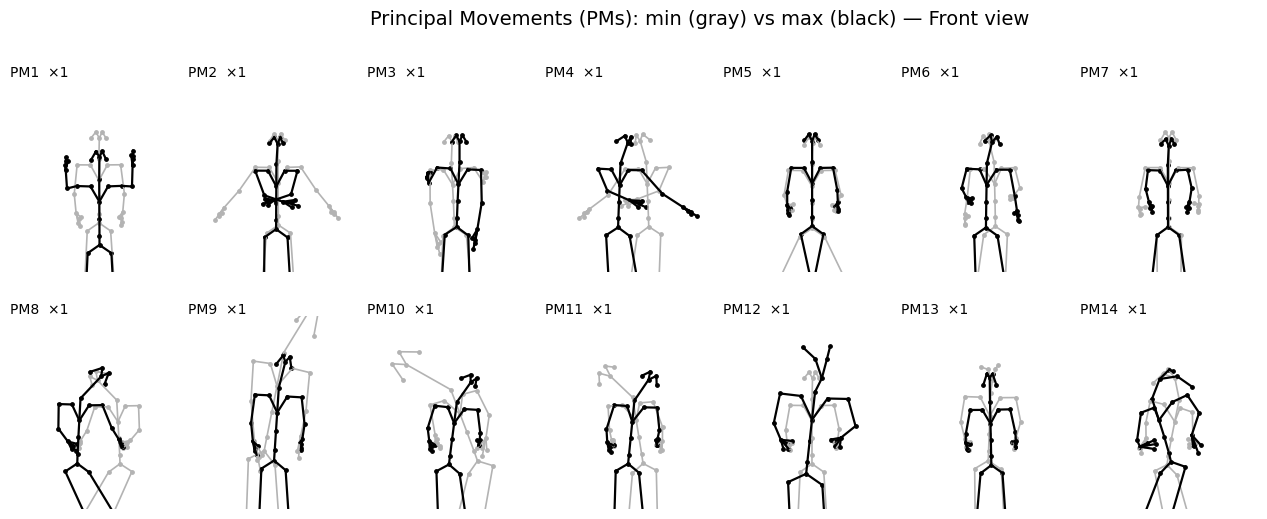

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def pose_from_pc(extreme_score, pc_idx, X_mean, pca, n_points):
    """Reconstruct 3D pose at given score along PC."""
    comp = pca.components_[pc_idx]              # shape: (n_points*3,)
    pose_vec = X_mean.ravel() + extreme_score * comp
    return pose_vec.reshape(n_points, 3)

def project(P, view="front"):
    """
    Project 3D (x,y,z) to 2D for plotting.
    front: (x, y)
    side : (z, y)  (sagittal)
    """
    if view == "front":
        return P[:, [0, 1]]
    elif view == "side":
        return P[:, [2, 1]]
    else:
        raise ValueError("view must be 'front' or 'side'")

def draw_skeleton(ax, P2, edges, color, lw=1.5, alpha=1.0):
    for i, j in edges:
        ax.plot([P2[i,0], P2[j,0]], [P2[i,1], P2[j,1]], color=color, lw=lw, alpha=alpha)
    ax.scatter(P2[:,0], P2[:,1], s=6, color=color, alpha=alpha)

def overlay_min_max(ax_front, ax_side, Pmin, Pmax, edges):
    Pf_min, Pf_max = project(Pmin,"front"), project(Pmax,"front")
    Ps_min, Ps_max = project(Pmin,"side"),  project(Pmax,"side")
    draw_skeleton(ax_front, Pf_min, edges, color="0.7", lw=1.2) # gray
    draw_skeleton(ax_front, Pf_max, edges, color="0.0", lw=1.6) # black
    draw_skeleton(ax_side,  Ps_min, edges, color="0.7", lw=1.2)
    draw_skeleton(ax_side,  Ps_max, edges, color="0.0", lw=1.6)
    # tidy
    for ax in (ax_front, ax_side):
        ax.set_aspect('equal')
        ax.axis('off')
# Collect global scores for each PC to find min/max
scores_all = np.vstack(pc_scores)      # shape: (sum_T, n_components)
pc_mins = scores_all.min(axis=0)
pc_maxs = scores_all.max(axis=0)

def rms_displacement(Pmin, Pmax):
    """RMS distance per joint across the posture pair."""
    D = np.linalg.norm(Pmax - Pmin, axis=1)   # per-joint 3D distance
    return np.sqrt((D**2).mean())

# Compute a per-PC amplification so the RMS shift hits a target
TARGET_RMS = 0.25  # tweak for visual clarity (units of your normalised coordinates)

amp_factors = []
for pc in range(pca.n_components_):
    # raw min/max poses (no amplification yet)
    Pmin_raw = pose_from_pc(pc_mins[pc], pc, X_mean, pca, n_points)
    Pmax_raw = pose_from_pc(pc_maxs[pc], pc, X_mean, pca, n_points)
    base_rms = rms_displacement(Pmin_raw, Pmax_raw)
    if base_rms <= 1e-12:
        amp = 1.0
    else:
        amp = TARGET_RMS / base_rms
    # quantize the label to nice steps (×1, ×1.5, ×2, ×3)
    if amp < 1.25:   label = "×1"
    elif amp < 1.75: label = "×1.5"
    elif amp < 2.5:  label = "×2"
    elif amp < 3.5:  label = "×3"
    else:            label = f"×{amp:.1f}"
    amp_factors.append((amp, label))

# --- helper: front-view overlay only ---
def overlay_min_max_front(ax, Pmin, Pmax, edges):
    Pf_min = Pmin[:, [0, 1]]
    Pf_max = Pmax[:, [0, 1]]
    draw_skeleton(ax, Pf_min, edges, color="0.7", lw=1.2)  # gray (min)
    draw_skeleton(ax, Pf_max, edges, color="0.0", lw=1.6)  # black (max)
    ax.set_aspect('equal')
    ax.axis('off')

# --- figure: 15 PCs in two rows (7 + 8) ---
N = min(15, pca.n_components_)
layout = [7, 8]   # first row = 7, second = 8
total_cols = max(layout)
nrows = len(layout)

fig = plt.figure(figsize=(total_cols * 2.3, nrows * 3.0))
fig.suptitle("Principal Movements (PMs): min (gray) vs max (black) — Front view", fontsize=14, y=0.97)

pc_idx = 0
for r, ncols in enumerate(layout):
    for c in range(ncols):
        if pc_idx >= N:
            break

        amp, amp_label = amp_factors[pc_idx]
        comp = pca.components_[pc_idx]
        mu = X_mean.ravel()
        Pmin = (mu + amp * pc_mins[pc_idx] * comp).reshape(n_points, 3)
        Pmax = (mu + amp * pc_maxs[pc_idx] * comp).reshape(n_points, 3)

        ax = plt.subplot2grid((nrows, total_cols), (r, c))
        overlay_min_max_front(ax, Pmin, Pmax, edges)
        ax.set_title(f"PM{pc_idx+1}  {amp_label}", fontsize=10, loc='left', pad=1)
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(-0.3, 1.0)

        pc_idx += 1

plt.subplots_adjust(wspace=0.0002, hspace=0.05)
#plt.subplots_adjust(wspace=0.05, hspace=0.15, top=0.9, bottom=0.02, left=0.02, right=0.98)
plt.savefig(OUT_DIR / "figure_PMs_minmax_front_compact.svg", dpi=300)
plt.show()



### Leader/Follower Comparisons

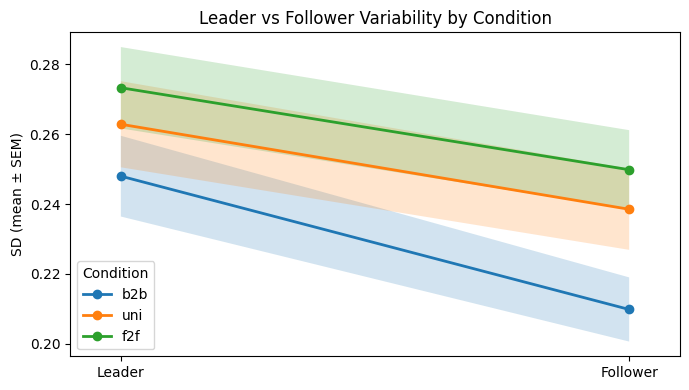

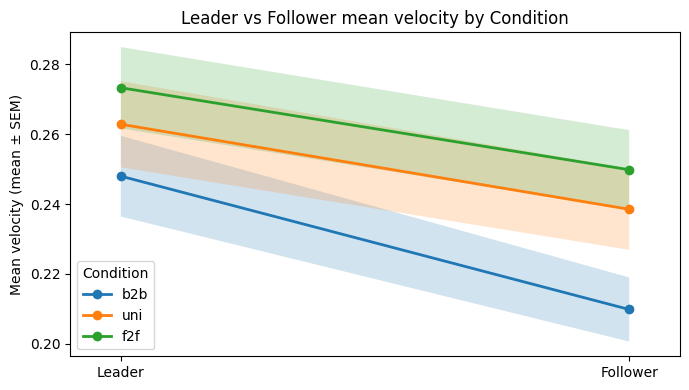

In [ ]:
from matplotlib import pyplot as plt   
import seaborn as sns

df_merged = pd.read_csv("CRQA_Stats_with_Conditions.csv")

# First, create Leader/Follower columns
df_merged['Leader_SD'] = df_merged.apply(
    lambda row: row['P1_SD'] if row['Leader'] == 'P1' else row['P2_SD'], 
    axis=1
)
df_merged['Follower_SD'] = df_merged.apply(
    lambda row: row['P2_SD'] if row['Leader'] == 'P1' else row['P1_SD'], 
    axis=1
)

# --- build leader/follower velocity columns from P1/P2 + Leader ---
df['leader_mean_velocity'] = df.apply(
    lambda r: r['P1_mean_velocity'] if r['Leader'] == 'P1' else r['P2_mean_velocity'], axis=1
)
df['follower_mean_velocity'] = df.apply(
    lambda r: r['P2_mean_velocity'] if r['Leader'] == 'P1' else r['P1_mean_velocity'], axis=1
)

# --- collapse to one row per (Condition, Pair) to avoid overweighting trials/PCs ---
pair_vel = (
    df.groupby(['Condition', 'Pair'], as_index=False)[['leader_mean_velocity','follower_mean_velocity']].mean()
)

# --- condition-level mean and SEM across pairs ---
cond_order = ['b2b', 'uni', 'f2f']
summary = (
    pair_vel.groupby('Condition')
    .agg(
        n=('Pair','nunique'),
        leader_mean=('leader_mean_velocity','mean'),
        follower_mean=('follower_mean_velocity','mean'),
        leader_sem =('leader_mean_velocity', lambda x: x.sem(ddof=1)),
        follower_sem=('follower_mean_velocity', lambda x: x.sem(ddof=1)),
    )
    .reindex(cond_order)
)


# Order conditions for consistent plotting
cond_order = ['b2b', 'uni', 'f2f']

# 1) Collapse to pair-level means (so each pair contributes once per condition)
pair_means = (
    df_merged
    .groupby(['Condition', 'Pair'], as_index=False)[['Leader_SD', 'Follower_SD']]
    .mean()
)

# 2) Compute condition-level mean and SEM across pairs
summary = (
    pair_means
    .groupby('Condition')
    .agg(
        n=('Pair', 'nunique'),
        leader_mean=('Leader_SD', 'mean'),
        follower_mean=('Follower_SD', 'mean'),
        leader_sem=('Leader_SD', lambda x: x.sem(ddof=1)),
        follower_sem=('Follower_SD', lambda x: x.sem(ddof=1)),
    )
    .reindex(cond_order)  # enforce plotting order
)

# 3) Plot: one line per condition (Leader -> Follower) with SEM shading
fig, ax = plt.subplots(figsize=(7, 4))
x = np.array([1, 2])  # 1 = Leader, 2 = Follower
ax.set_xticks(x)
ax.set_xticklabels(['Leader', 'Follower'])

for cond in summary.index:
    row = summary.loc[cond]
    y = np.array([row['leader_mean'], row['follower_mean']])
    y_sem = np.array([row['leader_sem'], row['follower_sem']])
    y_sem = np.nan_to_num(y_sem, nan=0.0)  # handle n=1 edge case

    ax.plot(x, y, marker='o', linewidth=2, label=cond)
    ax.fill_between(x, y - y_sem, y + y_sem, alpha=0.2)

ax.set_xlabel('')
ax.set_ylabel('SD (mean ± SEM)')
ax.set_title('Leader vs Follower Variability by Condition')
ax.legend(title='Condition')
ax.margins(x=0.1)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
x = np.array([1,2])
ax.set_xticks(x)
ax.set_xticklabels(['Leader','Follower'])

for cond in summary.index:
    row = summary.loc[cond]
    y = np.array([row['leader_mean'], row['follower_mean']])
    e = np.array([row['leader_sem'],  row['follower_sem']])
    e = np.nan_to_num(e, nan=0.0)  # handle n=1 edge cases

    ax.plot(x, y, marker='o', linewidth=2, label=cond)
    ax.fill_between(x, y - e, y + e, alpha=0.2)

ax.set_ylabel('Mean velocity (mean ± SEM)')
ax.set_title('Leader vs Follower mean velocity by Condition')
ax.legend(title='Condition')
ax.margins(x=0.1)
plt.tight_layout()
plt.show()

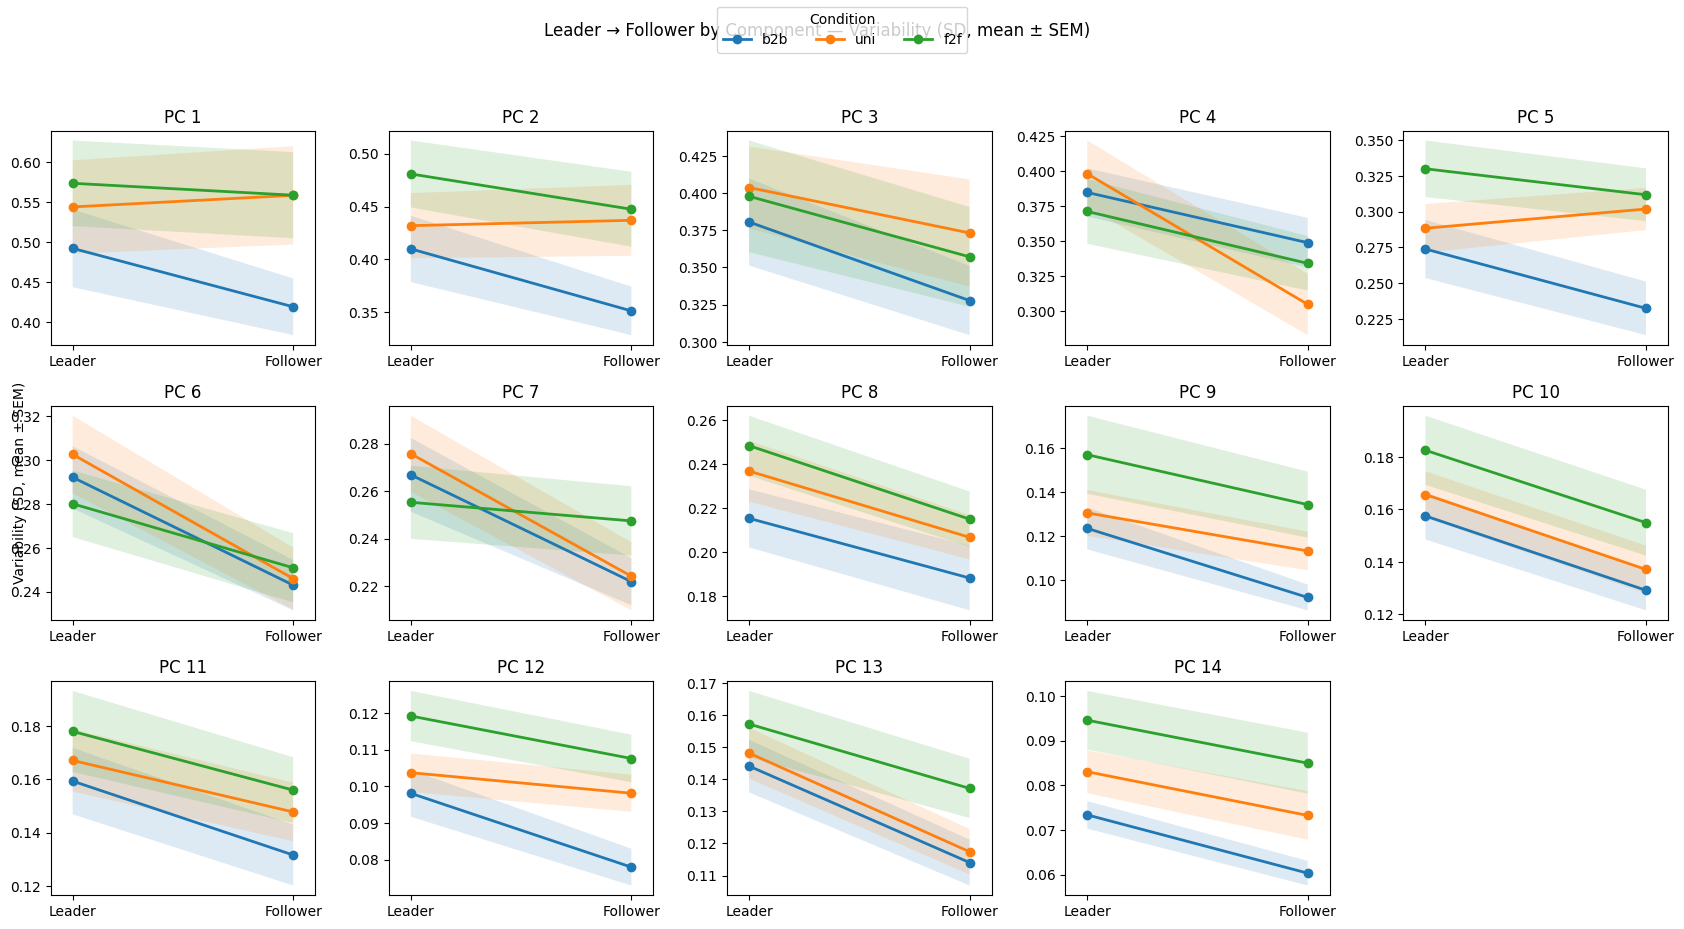

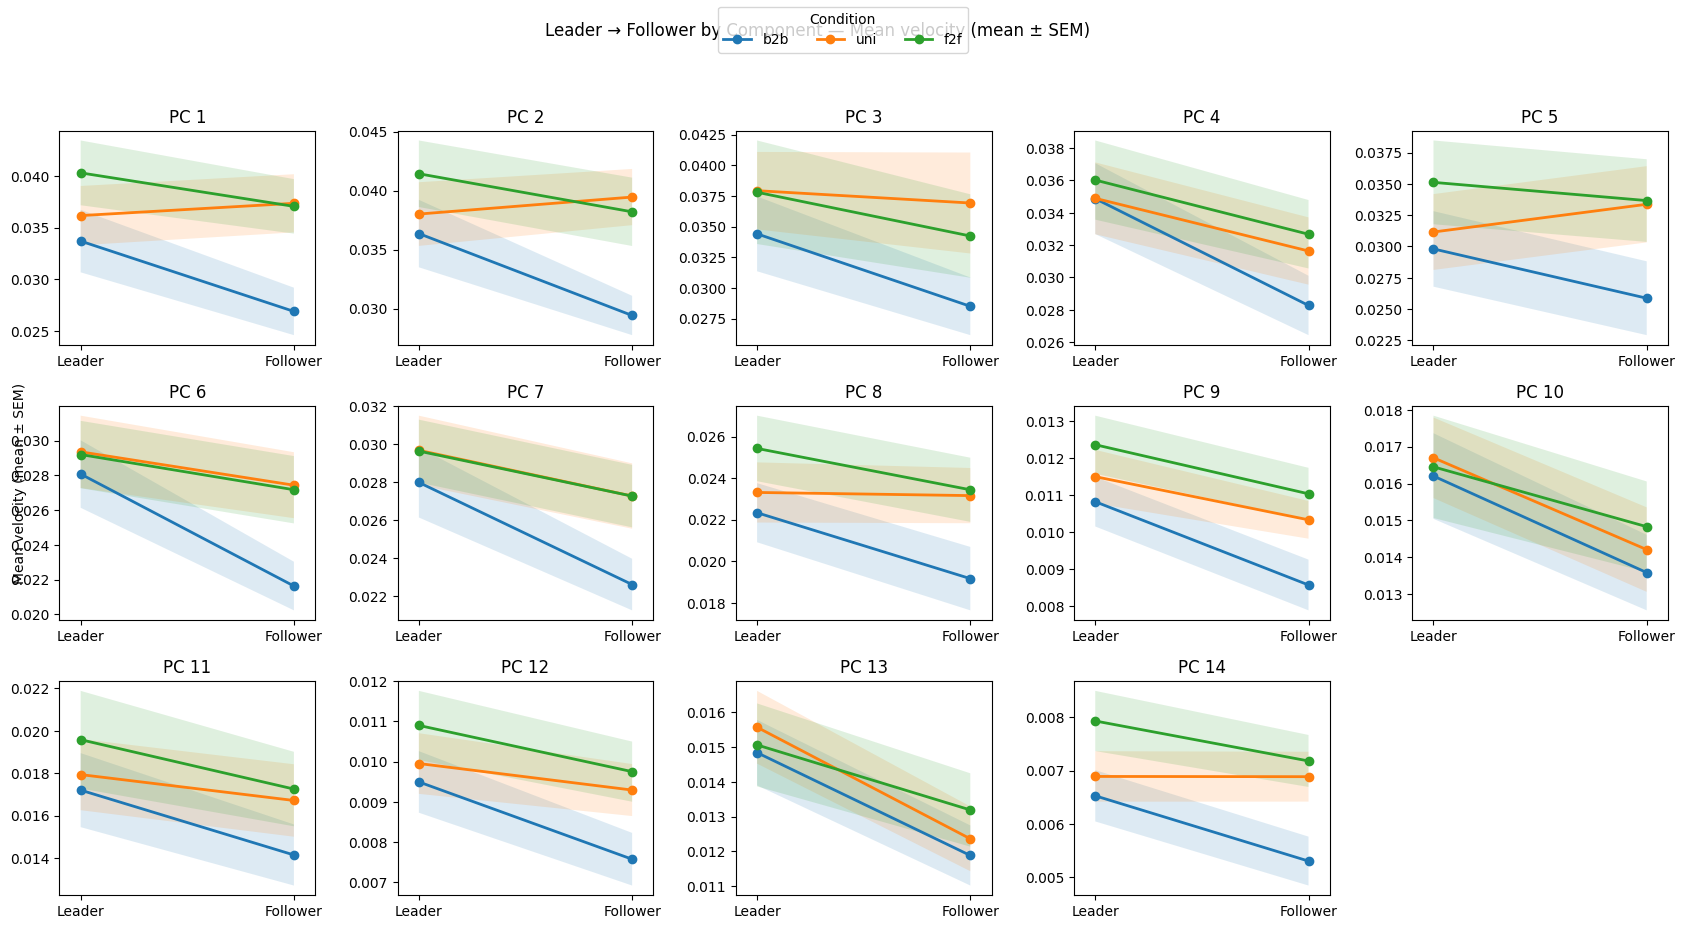

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# --- load ---
df = pd.read_csv("CRQA_Stats_with_Conditions.csv")

# --- Leader/Follower columns ---
df['Leader_SD']  = df.apply(lambda r: r['P1_SD'] if r['Leader']=='P1' else r['P2_SD'], axis=1)
df['Follower_SD']= df.apply(lambda r: r['P2_SD'] if r['Leader']=='P1' else r['P1_SD'], axis=1)
df['Leader_Vel'] = df.apply(lambda r: r['P1_mean_velocity'] if r['Leader']=='P1' else r['P2_mean_velocity'], axis=1)
df['Follower_Vel']=df.apply(lambda r: r['P2_mean_velocity'] if r['Leader']=='P1' else r['P1_mean_velocity'], axis=1)

cond_order = ['b2b','uni','f2f']
df = df[df['Condition'].isin(cond_order)]

# --- collapse within (Condition, PC, Pair) to avoid overweighting multiple trials ---
collapsed = (df.groupby(['Condition','PC','Pair'], as_index=False)
               .agg(Leader_SD=('Leader_SD','mean'),
                    Follower_SD=('Follower_SD','mean'),
                    Leader_Vel=('Leader_Vel','mean'),
                    Follower_Vel=('Follower_Vel','mean')))

# --- summary stats (mean ± SEM across pairs) ---
summary = (collapsed.groupby(['Condition','PC'])
           .agg(leader_SD_mean=('Leader_SD','mean'),
                follower_SD_mean=('Follower_SD','mean'),
                leader_SD_sem =('Leader_SD', lambda x: x.sem(ddof=1)),
                follower_SD_sem=('Follower_SD', lambda x: x.sem(ddof=1)),
                leader_Vel_mean=('Leader_Vel','mean'),
                follower_Vel_mean=('Follower_Vel','mean'),
                leader_Vel_sem =('Leader_Vel', lambda x: x.sem(ddof=1)),
                follower_Vel_sem=('Follower_Vel', lambda x: x.sem(ddof=1)))
           .reset_index())

pcs = sorted(summary['PC'].unique())
N = len(pcs)

def plot_grid(metric_label):
    # metric_label in {'SD','Vel'}
    means_leader   = f'leader_{metric_label}_mean'
    means_follower = f'follower_{metric_label}_mean'
    sem_leader     = f'leader_{metric_label}_sem'
    sem_follower   = f'follower_{metric_label}_sem'

    # layout
    cols = min(5, N)
    rows = math.ceil(N/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.2*rows), squeeze=False)
    x = np.array([1,2])

    for i, pc in enumerate(pcs):
        r, c = divmod(i, cols)
        ax = axes[r, c]

        for cond in cond_order:
            sub = summary[(summary['PC']==pc) & (summary['Condition']==cond)]
            if sub.empty:
                continue
            y  = np.array([sub[means_leader].values[0], sub[means_follower].values[0]])
            se = np.array([sub[sem_leader].values[0],   sub[sem_follower].values[0]])
            se = np.nan_to_num(se, nan=0.0)

            ax.plot(x, y, marker='o', linewidth=2, label=cond)
            ax.fill_between(x, y-se, y+se, alpha=0.15)

        ax.set_xticks(x); ax.set_xticklabels(['Leader','Follower'])
        ax.set_title(f'PC {pc}')
        ax.margins(x=0.1)

    # remove any empty axes
    for j in range(N, rows*cols):
        r, c = divmod(j, cols)
        fig.delaxes(axes[r, c])

    ylabel = 'Variability (SD, mean ± SEM)' if metric_label=='SD' \
             else 'Mean velocity (mean ± SEM)'
    fig.text(0.04, 0.5, ylabel, va='center', rotation='vertical')
    handles, labels = axes[0,0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title='Condition', loc='upper center', ncol=3)
    fig.suptitle(f'Leader → Follower by Component — {ylabel}', y=0.98)
    fig.tight_layout(rect=[0.03, 0.03, 1, 0.94])
    plt.show()

# --- Figure 1: variability per PC ---
plot_grid('SD')

# --- Figure 2: mean velocity per PC ---
plot_grid('Vel')


In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/cartersale/Documents/Pose_Dynamics/interpolation_results_noisy_sine.csv')

# Calculate statistics for each gap length
stats = df.groupby('gap_in_tau').agg({
    'RR_rel_error': ['mean', 'std'],
    'DET_rel_error': ['mean', 'std']
})

for gap in sorted(df['gap_in_tau'].unique()):
    rr_mean = stats.loc[gap, ('RR_rel_error', 'mean')]
    rr_std = stats.loc[gap, ('RR_rel_error', 'std')]
    det_mean = stats.loc[gap, ('DET_rel_error', 'mean')]
    det_std = stats.loc[gap, ('DET_rel_error', 'std')]
    print(f"{gap:.2f}τ: RR = {rr_mean:.1f}% ± {rr_std:.1f}%, DET = {det_mean:.1f}% ± {det_std:.1f}%")

0.48τ: RR = 0.2% ± 0.2%, DET = 0.5% ± 0.2%
1.00τ: RR = 1.0% ± 0.8%, DET = 0.6% ± 0.5%
1.48τ: RR = 3.7% ± 1.7%, DET = 1.0% ± 0.6%
2.00τ: RR = 7.0% ± 1.7%, DET = 1.4% ± 0.6%
3.00τ: RR = 9.1% ± 1.0%, DET = 0.8% ± 0.7%
4.00τ: RR = 9.4% ± 2.6%, DET = 2.7% ± 2.0%


# Mirror Game: Pose Dynamics Analysis

Full pipeline: Motion capture → PCA → CRQA → Statistical analysis

![Illustration](mirror_game_fig1.png)

## 1. Setup & Data Loading

Load and prepare Mirror Game dataset with 3 experimental conditions:
- **b2b** (back-to-back): no visual feedback
- **uni** (unidirectional): one partner sees the other
- **f2f** (face-to-face): mutual visual feedback

In [ ]:
import sys, os
from pathlib import Path

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parents[2] if (NB_DIR / "utils").exists() else NB_DIR.parents[1]
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from collections import defaultdict
from pose_dynamics.preprocessing import *
from pose_dynamics.geometry_utils import *
from pose_dynamics.io import *
from pose_dynamics.normalization import *
from pose_dynamics.rqa.crossRQA import crossRQA  
from pose_dynamics.rqa.multivariateRQA import multivariateRQA


# Adjust DATA_DIR and OUT_DIR and go
DATA_DIR = Path("/Users/cartersale/Documents/Pose_Dynamics/data/Mirror")
OUT_DIR  = NB_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Temporal Alignment

Resample to 30 Hz, synchronize, and trim dyadic sequences to equal length.

In [ ]:
# Alignment options
ALLOW_ROTATION = True
ALLOW_SCALE    = False   
REF_IDX        = None    
N_COMPONENTS   = 14 
TARGET_RATE    = 30.0 

MG_FILES = sorted(DATA_DIR.glob("*.csv"))
if not MG_FILES:
    raise SystemExit(f"No CSVs found in {DATA_DIR}")

# Expect: P001_T3_P1_pose_3d.csv
import re
MG_RE = re.compile(r"^(P\d{3})_(T\d+)_((?:P1|P2))_pose_3d\.csv$", re.IGNORECASE)

index = defaultdict(dict)  # {(pair,trial): {'P1': Path, 'P2': Path}}
bad = []

for f in MG_FILES:
    m = MG_RE.match(f.name)
    if not m:
        bad.append(f.name)
        continue
    pair_id, trial_id, party = m.group(1).upper(), m.group(2).upper(), m.group(3).upper()
    index[(pair_id, trial_id)][party] = f

print(f"Trials indexed: {len(index)} | Unparsed: {len(bad)}")
if bad[:5]: print("Unparsed sample:", bad[:5])

trial_groups = {}   # {(pair,trial): {'P1': (fname, df, cols), 'P2': (...)}}

for (pair_id, trial_id), parties in index.items():
    if "P1" not in parties or "P2" not in parties:
        continue

    f1, f2 = parties["P1"], parties["P2"]
    df1_raw = pd.read_csv(f1)
    df2_raw = pd.read_csv(f2)

    # 30 Hz resample using dt_ms
    df1 = resample(df1_raw, target_rate=TARGET_RATE)
    df2 = resample(df2_raw, target_rate=TARGET_RATE)

    # overlap + truncate to equal length
    df1_aligned, df2_aligned = align_pair(df1, df2)

    # xyz triplets present in each stream
    cols1 = order_xyz_triplets(df1_aligned.columns)
    cols2 = order_xyz_triplets(df2_aligned.columns)
    if not cols1 or not cols2:
        continue

    trial_groups[(pair_id, trial_id)] = {
        "P1": (f1.name, df1_aligned, cols1),
        "P2": (f2.name, df2_aligned, cols2),
    }

len(trial_groups)



Trials indexed: 216 | Unparsed: 2
Unparsed sample: ['rename_files.csv', 'rename_log.csv']


216

## 3. Spatial Alignment (Procrustes)

Center poses and build global template. Align all trials to canonical reference using Procrustes to remove position, scale, and orientation differences.

In [ ]:
# Stage 1: center/canonicalise per trial to build a global template
trials = []     # list of (fname, df, cols)
centred = []    # list of flattened arrays (T, n_points*3)

for key, parties in trial_groups.items():
    for party in ("P1", "P2"):
        fname, df, cols = parties[party]
        trials.append((fname, df, cols))
        arr_flat, _meta = align_keypoints_3d(
            df, expected_cols=cols, ref_idx=REF_IDX,
            template=None, use_procrustes=False,  # first pass: centre only
            allow_rotation=False, allow_scale=False
        )
        centred.append(arr_flat)

if not trials:
    raise SystemExit("No usable trials after preprocessing.")

n_points = len(trials[0][2]) // 3

# Build a global template from the centred sequences
template = build_template_with_canonicalisation(centred, n_points)
template.shape  # (n_points, 3)

(38, 3)

## 4. Dimensionality Reduction (PCA)

Extract Principal Movements (PMs) from 3D motion data. Each PM captures a fundamental mode of variation (e.g., swaying, reaching, rotation).

In [ ]:
# Canonicalise once per frame against the global template
all_aligned = []  # list of (T, n_points*3)

for (fname, df, cols), arr_flat in zip(trials, centred):
    arr_frames = arr_flat.reshape(-1, n_points, 3)
    canon_seq  = canonicalise_trial(arr_frames, template)  # shape: (T, n_points, 3)
    all_aligned.append(canon_seq.reshape(canon_seq.shape[0], -1))  # flatten per frame

# Stack and PCA
X = np.vstack(all_aligned)
X_mean = X.mean(0, keepdims=True)
X_mc   = X - X_mean

k = min(N_COMPONENTS, X_mc.shape[1])
pca = PCA(n_components=k).fit(X_mc)
evr = pca.explained_variance_ratio_ * 100.0
print("Explained variance:", ", ".join(f"PC{i+1}:{v:.2f}%" for i,v in enumerate(evr)))

# Save PCA parts
np.save(OUT_DIR / "pca_components.npy", pca.components_)
np.save(OUT_DIR / "pca_mean.npy",       X_mean.squeeze())
with open(OUT_DIR / "pca_explained_variance.txt", "w") as f:
    for i, v in enumerate(evr, 1):
        f.write(f"PC{i}: {v:.4f}%\n")

# Keep mapping from trial index -> (pair_trial, party)
pair_trials = []   # parallel to trials list
for (pair_id, trial_id), parties in trial_groups.items():
    for party in ("P1", "P2"):
        pair_trials.append((f"{pair_id}_{trial_id}", party))

pc_scores = [pca.transform(arr) for arr in all_aligned]  # list of (T, k)

# Save per-trial PC scores for reproducibility
OUT_PC = OUT_DIR / "pc_scores"
OUT_PC.mkdir(parents=True, exist_ok=True)

for (pair_trial, party), scores in zip(pair_trials, pc_scores):
    np.save(OUT_PC / f"{pair_trial}_{party}_pc.npy", scores)


Explained variance: PC1:28.47%, PC2:15.47%, PC3:10.58%, PC4:9.89%, PC5:6.34%, PC6:5.64%, PC7:4.75%, PC8:3.57%, PC9:2.57%, PC10:2.30%, PC11:2.01%, PC12:1.80%, PC13:1.40%, PC14:0.69%


## 5. Cross-Recurrence Quantification (CRQA)

Quantify dyadic coordination using CRQA metrics:
- **%REC**: Recurrence rate (how often similar states occur)
- **%DET**: Determinism (structure/predictability)
- **Entropy**, **Laminarity**, **Trapping Time**: Pattern complexity and persistence

In [ ]:
from pose_dynamics.pc_rqa_utils import run_pc_rqa_analysis, merge_pc_rqa_with_conditions

# RQA params
RQA_PARAMS = dict(
    eDim=4,          # embedding dimension
    tLag=10,         # time lag
    radius=0.20,     # recurrence threshold
    minl=2,          # minimum diagonal line length
    rescaleNorm=1,   # 1: mean-distance rescale
    norm=2,          # z-score normalization
)

# Run CRQA on PCs
print("Running Cross-RQA on Principal Components...")
df_crqa = run_pc_rqa_analysis(
    pc_scores=pc_scores,
    pair_trials=pair_trials,
    params=RQA_PARAMS,
    verbose=True
)

# Save results
df_crqa.to_csv(OUT_DIR / "crqa_by_pc.csv", index=False)
print(f"\nSaved {len(df_crqa)} CRQA results")

# Merge with conditions
try:
    merged = merge_pc_rqa_with_conditions(
        df_crqa,
        conditions_csv="Mirror_Game_Conditions.csv",
        verbose=True
    )
    merged.to_csv("CRQA_Stats_with_Conditions.csv", index=False)
    print("Saved merged results to CRQA_Stats_with_Conditions.csv")
    display(merged.head())
except FileNotFoundError:
    print("Conditions file not found. Skipping merge.")
    merged = df_crqa
    display(df_crqa.head())

## 6. Multivariate Recurrence

### 6a. Multivariate RQA on Keypoints

Run mdRQA directly on aligned keypoints (instead of PCs) with flexible options:

**Keypoint modes**: all (114D) | xy_only (76D) | subset (custom)  
**RQA modes**: auto (individual) | cross (dyadic) | joint (combined)

### 6b. Multivariate Recurrence on PCs

#### Setup

In [ ]:
from pathlib import Path
import numpy as np, pandas as pd
from pose_dynamics.rqa.multivariateRQA import multivariateRQA

OUT_DIR = OUT_DIR  # you already defined this earlier
K_MDRQA = 8        # try [3,5,8,12] for sensitivity

# MdRQA expects string norms (e.g., 'zscore'), not numeric codes
BASE_PARAMS = dict(RQA_PARAMS)
BASE_PARAMS.update({
    'norm': 'zscore',
    'rescaleNorm': 1,
    'radius': 0.30,   # tune to reach ~2–5% REC for chosen K; then keep fixed for that K
    'minl': 2,
    'tw': 1,
    'plotMode': None,
    'pointSize': 1,
    'showMetrics': False,
    'saveFig': False,
    'doStatsFile': False,
})

def parse_pair_trial(df, col='pair_trial'):
    pt = df[col].str.extract(r"P(\d+)_T(\d+)")
    pt.columns = ["Pair","Trial"]
    df["Pair"]  = pt["Pair"].astype(int)
    df["Trial"] = pt["Trial"].astype(int)
    return df

def add_conditions(df, cond_long):
    # cond_long has columns: Pair, Trial, Condition, Leader
    out = df.merge(cond_long, on=["Pair","Trial"], how="left")
    return out


NameError: name 'RQA_PARAMS' is not defined

#### MdRQA (Auto) - per participant
How structured/stable is each person’s own K-D movement?

In [ ]:
MDRQA_PARAMS = dict(BASE_PARAMS)

rows = []
for pair_trial, pmap in pair_to_indices.items():
    if 'P1' not in pmap or 'P2' not in pmap: 
        continue
    i1, i2 = pmap['P1'], pmap['P2']
    pcs1, pcs2 = pc_scores[i1], pc_scores[i2]
    T = min(pcs1.shape[0], pcs2.shape[0])

    for party, pcs in (('P1', pcs1), ('P2', pcs2)):
        X = pcs[:T, :K_MDRQA]    # (T, K)
        td, rs, mats, err = multivariateRQA(X, MDRQA_PARAMS, mode='auto')
        row = {'pair_trial': pair_trial, 'party': party, 'K': K_MDRQA, 'error': int(err)}
        if err == 0:
            row.update({k: float(v) for k, v in rs.items()})
            row['SD_mean']  = float(np.std(X, axis=0).mean())
            row['Vel_mean'] = float(np.mean(np.abs(np.diff(X, axis=0)), axis=0).mean())
        rows.append(row)

df_mdrqa = pd.DataFrame(rows)
df_mdrqa = parse_pair_trial(df_mdrqa, 'pair_trial')
df_mdrqa = add_conditions(df_mdrqa, cond_long)
df_mdrqa['Role'] = np.where(df_mdrqa['party'] == df_mdrqa['Leader'], 'Leader', 'Follower')

out_auto = OUT_DIR / f"mdrqa_auto_top{K_MDRQA}_pcs_with_conditions.csv"
df_mdrqa.to_csv(out_auto, index=False)
print(f"Saved {out_auto}")


Saved results/mdrqa_auto_top8_pcs_with_conditions.csv


#### MdCRQA (Cross) — P1 vs P2 in K-D PC space
How coupled/synchronized are the two participants?

In [ ]:
MDCRQA_PARAMS = dict(BASE_PARAMS)

rows = []
for pair_trial, pmap in pair_to_indices.items():
    if 'P1' not in pmap or 'P2' not in pmap: 
        continue
    i1, i2 = pmap['P1'], pmap['P2']
    pcs1, pcs2 = pc_scores[i1], pc_scores[i2]
    T = min(pcs1.shape[0], pcs2.shape[0])
    X = pcs1[:T, :K_MDRQA]   # P1 (T,K)
    Y = pcs2[:T, :K_MDRQA]   # P2 (T,K)

    td, rs, mats, err = multivariateRQA([X, Y], MDCRQA_PARAMS, mode='cross')
    row = {'pair_trial': pair_trial, 'K': K_MDRQA, 'error': int(err)}
    if err == 0:
        row.update({k: float(v) for k, v in rs.items()})
        # simple linear companions
        row['Leader_SD']    = float(np.std(X, axis=0).mean())
        row['Follower_SD']  = float(np.std(Y, axis=0).mean())
        row['Leader_Vel']   = float(np.mean(np.abs(np.diff(X, axis=0)), axis=0).mean())
        row['Follower_Vel'] = float(np.mean(np.abs(np.diff(Y, axis=0)), axis=0).mean())
    rows.append(row)

df_mdcrqa = pd.DataFrame(rows)
df_mdcrqa = parse_pair_trial(df_mdcrqa, 'pair_trial')
df_mdcrqa = add_conditions(df_mdcrqa, cond_long)

out_cross = OUT_DIR / f"mdcrqa_cross_top{K_MDRQA}_pcs_with_conditions.csv"
df_mdcrqa.to_csv(out_cross, index=False)
print(f"Saved {out_cross}")


Saved results/mdcrqa_cross_top8_pcs_with_conditions.csv


#### Joint-space MdRQA (AUTO on [P1|P2] concatenated)
How structured is the dyad as a single system?

In [ ]:
JOINT_PARAMS = dict(BASE_PARAMS)

rows = []
for pair_trial, pmap in pair_to_indices.items():
    if 'P1' not in pmap or 'P2' not in pmap: 
        continue
    i1, i2 = pmap['P1'], pmap['P2']
    pcs1, pcs2 = pc_scores[i1], pc_scores[i2]
    T = min(pcs1.shape[0], pcs2.shape[0])
    X1 = pcs1[:T, :K_MDRQA]
    X2 = pcs2[:T, :K_MDRQA]
    Z  = np.concatenate([X1, X2], axis=1)     # (T, 2K)
    Z = whiten(Z)

    td, rs, mats, err = multivariateRQA(Z, JOINT_PARAMS, mode='auto')
    row = {'pair_trial': pair_trial, 'K_total': Z.shape[1], 'error': int(err)}
    if err == 0:
        row.update({k: float(v) for k, v in rs.items()})
        row['SD_mean']  = float(np.std(Z, axis=0).mean())
        row['Vel_mean'] = float(np.mean(np.abs(np.diff(Z, axis=0)), axis=0).mean())
    rows.append(row)

df_joint = pd.DataFrame(rows)
df_joint = parse_pair_trial(df_joint, 'pair_trial')
df_joint = add_conditions(df_joint, cond_long)

out_joint = OUT_DIR / f"mdrqa_jointspace_{2*K_MDRQA}d_with_conditions.csv"
df_joint.to_csv(out_joint, index=False)
print(f"Saved {out_joint}")


Saved results/mdrqa_jointspace_16d_with_conditions.csv


## 7. Statistical Analysis

Repeated-measures ANOVAs and post-hoc tests for each PC and CRQA metric across conditions.

### Linear

#### Aggregated Components

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from statsmodels.stats.anova import AnovaRM

# Import stats utilities
sys.path.insert(0, str(Path.cwd().parent / "src"))
from pose_dynamics import stats_utils

# Setup
OUT_DIR = Path("results")
STATS_DIR = OUT_DIR / "statistics"
STATS_DIR.mkdir(parents=True, exist_ok=True)

# Load data
print("="*80)
print("LINEAR METRICS: Condition × Role Effects")
print("="*80)

df_crqa = pd.read_csv(OUT_DIR / "CRQA_Stats_with_Conditions.csv")
print(f"\nData: {len(df_crqa)} rows, {df_crqa['Pair'].nunique()} pairs")

# Create Leader/Follower columns
df_crqa['Leader_SD'] = df_crqa.apply(
    lambda r: r['P1_SD'] if r['Leader'] == 'P1' else r['P2_SD'], axis=1
)
df_crqa['Follower_SD'] = df_crqa.apply(
    lambda r: r['P2_SD'] if r['Leader'] == 'P1' else r['P1_SD'], axis=1
)
df_crqa['Leader_Vel'] = df_crqa.apply(
    lambda r: r['P1_mean_velocity'] if r['Leader'] == 'P1' else r['P2_mean_velocity'], axis=1
)
df_crqa['Follower_Vel'] = df_crqa.apply(
    lambda r: r['P2_mean_velocity'] if r['Leader'] == 'P1' else r['P1_mean_velocity'], axis=1
)

# Aggregate across PCs and trials
linear_metrics = ['Leader_SD', 'Follower_SD', 'Leader_Vel', 'Follower_Vel']
df_linear = stats_utils.aggregate_across_pcs(
    df_crqa,
    groupby_cols=['Pair', 'Trial', 'Condition', 'Leader'],
    metric_cols=linear_metrics
)
df_linear = df_linear.groupby(['Pair', 'Condition'], as_index=False)[linear_metrics].mean()

print(f"After aggregation: {len(df_linear)} rows\n")

# ============================================================================
# Test 1: Variability (SD)
# ============================================================================

print("--- VARIABILITY (SD) ---")
df_sd_long = stats_utils.prepare_leader_follower_data(
    df_linear, metric_prefix='SD', id_cols=['Condition', 'Pair']
)

try:
    aovrm = AnovaRM(df_sd_long, depvar='Value', subject='Pair', within=['Condition', 'Role'])
    res_sd = aovrm.fit()
    
    anova_table_sd = res_sd.anova_table.copy()
    
    # Calculate partial eta squared
    for effect in anova_table_sd.index:
        ss_effect = anova_table_sd.loc[effect, 'F Value'] * anova_table_sd.loc[effect, 'Num DF']
        ss_error = anova_table_sd.loc[effect, 'Den DF']
        anova_table_sd.loc[effect, 'partial_eta_sq'] = ss_effect / (ss_effect + ss_error)
    
    print("\n2-way RM-ANOVA: SD ~ Condition × Role")
    print(anova_table_sd)
    
    print("\nFormatted Results:")
    for effect in anova_table_sd.index:
        row = anova_table_sd.loc[effect]
        f_val = row['F Value']
        df_num = int(row['Num DF'])
        df_den = int(row['Den DF'])
        p_val = row['Pr > F']
        eta_sq = row['partial_eta_sq']
        
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
        
        print(f"  {effect:20s}: F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
    
    # Save
    anova_table_sd.to_csv(STATS_DIR / "linear_SD_anova.csv")
    
    # Post-hoc if Condition significant
    if anova_table_sd.loc['Condition', 'Pr > F'] < 0.05:
        print("\n  Condition effect significant! Post-hoc tests:")
        posthoc_sd = stats_utils.bonferroni_pairwise(df_sd_long, 'Value', 'Condition')
        for _, r in posthoc_sd.iterrows():
            if r['Significant']:
                print(f"    {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
        posthoc_sd.to_csv(STATS_DIR / "linear_SD_posthoc.csv", index=False)
    
    print("\n✓ SD analysis complete")
    
except Exception as e:
    print(f"\n❌ SD ANOVA failed: {e}")
    import traceback
    traceback.print_exc()

# ============================================================================
# Test 2: Mean Velocity
# ============================================================================

print("\n" + "="*80)
print("--- MEAN VELOCITY ---")
df_vel_long = stats_utils.prepare_leader_follower_data(
    df_linear, metric_prefix='Vel', id_cols=['Condition', 'Pair']
)

try:
    aovrm = AnovaRM(df_vel_long, depvar='Value', subject='Pair', within=['Condition', 'Role'])
    res_vel = aovrm.fit()
    
    anova_table_vel = res_vel.anova_table.copy()
    
    # Calculate partial eta squared
    for effect in anova_table_vel.index:
        ss_effect = anova_table_vel.loc[effect, 'F Value'] * anova_table_vel.loc[effect, 'Num DF']
        ss_error = anova_table_vel.loc[effect, 'Den DF']
        anova_table_vel.loc[effect, 'partial_eta_sq'] = ss_effect / (ss_effect + ss_error)
    
    print("\n2-way RM-ANOVA: Velocity ~ Condition × Role")
    print(anova_table_vel)
    
    print("\nFormatted Results:")
    for effect in anova_table_vel.index:
        row = anova_table_vel.loc[effect]
        f_val = row['F Value']
        df_num = int(row['Num DF'])
        df_den = int(row['Den DF'])
        p_val = row['Pr > F']
        eta_sq = row['partial_eta_sq']
        
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
        
        print(f"  {effect:20s}: F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
    
    # Save
    anova_table_vel.to_csv(STATS_DIR / "linear_Velocity_anova.csv")
    
    # Post-hoc if Condition significant
    if anova_table_vel.loc['Condition', 'Pr > F'] < 0.05:
        print("\n  Condition effect significant! Post-hoc tests:")
        posthoc_vel = stats_utils.bonferroni_pairwise(df_vel_long, 'Value', 'Condition')
        for _, r in posthoc_vel.iterrows():
            if r['Significant']:
                print(f"    {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
        posthoc_vel.to_csv(STATS_DIR / "linear_Velocity_posthoc.csv", index=False)
    
    print("\n✓ Velocity analysis complete")
    
    
except Exception as e:
    print(f"\n❌ Velocity ANOVA failed: {e}")
    import traceback
    traceback.print_exc()

# ============================================================================
# Simple Effects for Significant Condition × Role Interaction (Velocity)
# ============================================================================

print("\n" + "="*80)
print("SIMPLE-EFFECTS ANALYSIS (Velocity Interaction)")
print("="*80)

try:
    # ------------------------------------------------------------
    # 1. Compute leader–follower difference within each Pair/Condition
    # ------------------------------------------------------------
    df_delta = df_linear.copy()
    df_delta["Delta_Vel"] = df_delta["Leader_Vel"] - df_delta["Follower_Vel"]

    # pivot so we can do paired comparisons
    df_pivot = df_delta.pivot(index="Pair", columns="Condition", values="Delta_Vel")

    # Ensure correct condition order (if names differ, update here)
    conds = list(df_pivot.columns)

    print("\nLeader–Follower Velocity Differences (per Pair):")
    print(df_pivot.round(3))

    # ------------------------------------------------------------
    # 2. Simple effects: Leader vs Follower within each condition
    # ------------------------------------------------------------
    print("\n--- Simple Effects: Role difference within each Condition ---")
    simple_role_tests = []

    for cond in conds:
        # Extract leader/follower for this condition (already aggregated)
        df_cond = df_vel_long[df_vel_long["Condition"] == cond]

        # leader vs follower
        leader_vals = df_cond[df_cond["Role"] == "Leader"]["Value"]
        follower_vals = df_cond[df_cond["Role"] == "Follower"]["Value"]

        # Paired t-test
        from scipy.stats import ttest_rel
        t_stat, p_val = ttest_rel(leader_vals, follower_vals)

        # Cohen’s d for paired
        d = (leader_vals.mean() - follower_vals.mean()) / \
            (df_cond.groupby("Pair")["Value"].diff().dropna().std())

        simple_role_tests.append((cond, t_stat, p_val, d))
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"{cond}: t = {t_stat:.2f}, p = {p_val:.3f}, d = {d:.2f} {sig}")

    # ------------------------------------------------------------
    # 3. Compare deltas between conditions: Δ_condition comparisons
    # ------------------------------------------------------------
    print("\n--- Comparisons of Leader–Follower Gap Across Conditions ---")
    from itertools import combinations
    paired_delta_tests = []

    for c1, c2 in combinations(conds, 2):
        t_stat, p_val = ttest_rel(df_pivot[c1], df_pivot[c2])

        # Cohen’s d for paired deltas
        d = (df_pivot[c1].mean() - df_pivot[c2].mean()) / \
            (df_pivot[c1] - df_pivot[c2]).std()

        paired_delta_tests.append((c1, c2, t_stat, p_val, d))
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"{c1} vs {c2}: t = {t_stat:.2f}, p = {p_val:.3f}, d = {d:.2f} {sig}")

    print("\n✓ Simple-effects analysis complete\n")

except Exception as e:
    print(f"\n❌ Simple-effects analysis failed: {e}")
    import traceback
    traceback.print_exc()

# ============================================================================
# Summary
# ============================================================================

print("\n" + "="*80)
print("LINEAR METRICS SUMMARY")
print("="*80)

try:
    print("\nVariability (SD):")
    for effect in anova_table_sd.index:
        p = anova_table_sd.loc[effect, 'Pr > F']
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"  {effect:20s}: {sig}")
except:
    print("\nVariability (SD): Failed")

try:
    print("\nMean Velocity:")
    for effect in anova_table_vel.index:
        p = anova_table_vel.loc[effect, 'Pr > F']
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"  {effect:20s}: {sig}")
except:
    print("\nMean Velocity: Failed")

print("\n" + "="*80)

LINEAR METRICS: Condition × Role Effects

Data: 3024 rows, 18 pairs
After aggregation: 54 rows

--- VARIABILITY (SD) ---

2-way RM-ANOVA: SD ~ Condition × Role
                  F Value  Num DF  Den DF        Pr > F  partial_eta_sq
Condition       14.632639     2.0    34.0  2.602133e-05        0.462580
Role            68.036123     1.0    17.0  2.401031e-07        0.800085
Condition:Role   2.837633     2.0    34.0  7.249435e-02        0.143043

Formatted Results:
  Condition           : F(2, 34) = 14.63, p < .001, η²p = 0.463 ***
  Role                : F(1, 17) = 68.04, p < .001, η²p = 0.800 ***
  Condition:Role      : F(2, 34) = 2.84, p = 0.072, η²p = 0.143 ns

  Condition effect significant! Post-hoc tests:
    b2b vs f2f: p=0.000, d=-0.67
    b2b vs uni: p=0.002, d=-0.44
    f2f vs uni: p=0.007, d=0.22

✓ SD analysis complete

--- MEAN VELOCITY ---

2-way RM-ANOVA: Velocity ~ Condition × Role
                  F Value  Num DF  Den DF    Pr > F  partial_eta_sq
Condition       18.906

#### Per-Component

In [ ]:
# =============================================================================
# PER-COMPONENT ANALYSIS: SD & Velocity
# =============================================================================

print("\n" + "="*80)
print("PER-COMPONENT ANALYSIS: SD & Velocity")
print("="*80)

# Identify all PCs in the dataset
pcs = sorted(df_crqa["PC"].unique())
print(f"Detected {len(pcs)} PCs:", pcs)

per_pc_results_sd = []
per_pc_results_vel = []

for pc in pcs:
    print(f"\n--- PC {pc}: Running SD and Velocity ANOVAs ---")

    # -----------------------------
    # 1. Subset to this component
    # -----------------------------
    df_pc = df_crqa[df_crqa["PC"] == pc].copy()

    # -----------------------------
    # 2. Compute Leader/Follower vars
    # -----------------------------
    df_pc['Leader_SD'] = df_pc.apply(
        lambda r: r['P1_SD'] if r['Leader'] == 'P1' else r['P2_SD'], axis=1
    )
    df_pc['Follower_SD'] = df_pc.apply(
        lambda r: r['P2_SD'] if r['Leader'] == 'P1' else r['P1_SD'], axis=1
    )
    df_pc['Leader_Vel'] = df_pc.apply(
        lambda r: r['P1_mean_velocity'] if r['Leader'] == 'P1' else r['P2_mean_velocity'], axis=1
    )
    df_pc['Follower_Vel'] = df_pc.apply(
        lambda r: r['P2_mean_velocity'] if r['Leader'] == 'P1' else r['P1_mean_velocity'], axis=1
    )

    # -----------------------------
    # 3. Aggregate within trial
    # -----------------------------
    df_pc_lin = df_pc.groupby(
        ["Pair", "Trial", "Condition", "Leader"],
        as_index=False
    )[["Leader_SD", "Follower_SD", "Leader_Vel", "Follower_Vel"]].mean()

    # -----------------------------
    # 4. Aggregate across trials → Pair × Condition
    # -----------------------------
    df_pc_lin = df_pc_lin.groupby(
        ["Pair", "Condition"], as_index=False
    )[["Leader_SD", "Follower_SD", "Leader_Vel", "Follower_Vel"]].mean()

    # -----------------------------
    # 5. SD Analysis
    # -----------------------------
    df_sd_long = stats_utils.prepare_leader_follower_data(
        df_pc_lin, metric_prefix='SD', id_cols=['Condition', 'Pair']
    )

    try:
        aov_sd = AnovaRM(df_sd_long, depvar='Value',
                         subject='Pair', within=['Condition', 'Role']).fit()

        tbl = aov_sd.anova_table.copy()
        # Partial eta squared
        for eff in tbl.index:
            ss_eff = tbl.loc[eff, 'F Value'] * tbl.loc[eff, 'Num DF']
            ss_err = tbl.loc[eff, 'Den DF']
            tbl.loc[eff, 'eta_p'] = ss_eff / (ss_eff + ss_err)

        per_pc_results_sd.append({
            "PC": pc,
            "anova": tbl
        })

    except Exception as e:
        print(f"SD ANOVA failed for PC {pc}: {e}")
        per_pc_results_sd.append({
            "PC": pc,
            "anova": None,
            "error": str(e)
        })

    # -----------------------------
    # 6. Velocity Analysis
    # -----------------------------
    df_vel_long = stats_utils.prepare_leader_follower_data(
        df_pc_lin, metric_prefix='Vel', id_cols=['Condition', 'Pair']
    )

    try:
        aov_vel = AnovaRM(df_vel_long, depvar='Value',
                          subject='Pair', within=['Condition', 'Role']).fit()

        tbl = aov_vel.anova_table.copy()
        for eff in tbl.index:
            ss_eff = tbl.loc[eff, 'F Value'] * tbl.loc[eff, 'Num DF']
            ss_err = tbl.loc[eff, 'Den DF']
            tbl.loc[eff, 'eta_p'] = ss_eff / (ss_eff + ss_err)

        per_pc_results_vel.append({
            "PC": pc,
            "anova": tbl
        })

    except Exception as e:
        print(f"Velocity ANOVA failed for PC {pc}: {e}")
        per_pc_results_vel.append({
            "PC": pc,
            "anova": None,
            "error": str(e)
        })


# =============================================================================
# SAVE OUTPUTS
# =============================================================================

pd.DataFrame([
    {"PC": r["PC"], **(r["anova"].to_dict()['F Value'] if r["anova"] is not None else {})}
    for r in per_pc_results_sd
]).to_csv(STATS_DIR / "per_component_SD_summary.csv", index=False)

pd.DataFrame([
    {"PC": r["PC"], **(r["anova"].to_dict()['F Value'] if r["anova"] is not None else {})}
    for r in per_pc_results_vel
]).to_csv(STATS_DIR / "per_component_Vel_summary.csv", index=False)

print("\n✓ Per-component analysis complete.")



PER-COMPONENT ANALYSIS: SD & Velocity
Detected 14 PCs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]

--- PC 1: Running SD and Velocity ANOVAs ---

--- PC 2: Running SD and Velocity ANOVAs ---

--- PC 3: Running SD and Velocity ANOVAs ---

--- PC 4: Running SD and Velocity ANOVAs ---

--- PC 5: Running SD and Velocity ANOVAs ---

--- PC 6: Running SD and Velocity ANOVAs ---

--- PC 7: Running SD and Velocity ANOVAs ---

--- PC 8: Running SD and Velocity ANOVAs ---

--- PC 9: Running SD and Velocity ANOVAs ---

--- PC 10: Running SD and Velocity ANOVAs ---

--- PC 11: Running SD and Velocity ANOVAs ---

--- PC 12: Running SD and Velocity ANOVAs ---

--- PC 13: Running SD and Velocity ANOVAs ---

--- PC 14: Running SD and Velocity ANOVAs ---

✓ Per-component analysis complete.


### CRQA

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import itertools
from scipy.stats import ttest_rel

# Import stats utilities
sys.path.insert(0, str(Path.cwd().parent / "src"))
from pose_dynamics import stats_utils

# Setup
OUT_DIR = Path("results")
STATS_DIR = OUT_DIR / "statistics"
STATS_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Load data
# =============================================================================
print("="*80)
print("CRQA METRICS: Condition Effects on Coordination")
print("="*80)

df_crqa = pd.read_csv(OUT_DIR / "CRQA_Stats_with_Conditions.csv")
print(f"\nData: {len(df_crqa)} rows, {df_crqa['Pair'].nunique()} pairs, {len(df_crqa['PC'].unique())} PCs")

# =============================================================================
# Detect available CRQA columns
# =============================================================================

possible_crqa_cols = {
    'perc_recur': 'RR',
    'perc_determ': 'DET',
    'laminarity': 'LAM',
    'entropy': 'ENTR',
    'RR': 'RR',
    'DET': 'DET',
    'LAM': 'LAM',
    'ENTR': 'ENTR',
    'complexity': 'complexity',
    'mal_found': 'Lmax',
    'trend_lower_diag': 'trend_lower',
    'trend_upper_diag': 'trend_upper',
    'mean_linea_length': 'Lmean',
    'std_line_length': 'Lstd',
    'trapping_time': 'trapping_time',
    'vmax': 'vmax',
    'divergence': 'divergence',
}

crqa_metrics = []
crqa_metrics_std = []
for col, std_name in possible_crqa_cols.items():
    if col in df_crqa.columns:
        crqa_metrics.append(col)
        crqa_metrics_std.append(std_name)

# Remove duplicates by standardized name
seen = set()
unique_metrics = []
unique_std = []
for m, s in zip(crqa_metrics, crqa_metrics_std):
    if s not in seen:
        unique_metrics.append(m)
        unique_std.append(s)
        seen.add(s)

crqa_metrics = unique_metrics
crqa_metrics_std = unique_std

print(f"Analyzing CRQA metrics: {crqa_metrics_std}\n")

# =============================================================================
# Helper: PC-level post-hocs with Holm–Bonferroni
# =============================================================================

def run_pc_posthoc_holm(df, metric, pc, subject='Pair'):
    """
    Run paired post-hoc comparisons between conditions for a single PC and metric.
    Uses Holm–Bonferroni correction across the three condition pairs.
    
    Returns a DataFrame with:
    PC, Metric, Group1, Group2, t, p_raw, p_corrected, d, Significant
    """
    df_pc = df[df['PC'] == pc].copy()
    
    # Pivot to Pair × Condition for clean within-subject comparisons
    pivot = df_pc.pivot_table(
        index=subject,
        columns='Condition',
        values=metric
    )
    
    # Conditions present in this PC (we expect 'b2b','uni','f2f' but don't hard-code)
    available_conditions = list(pivot.columns)
    if len(available_conditions) < 2:
        return pd.DataFrame()  # not enough levels to compare
    
    pairs = list(itertools.combinations(available_conditions, 2))
    rows = []
    
    for g1, g2 in pairs:
        x = pivot[g1].dropna()
        y = pivot[g2].dropna()
        
        # Align indices
        common_idx = x.index.intersection(y.index)
        x = x.loc[common_idx]
        y = y.loc[common_idx]
        
        if len(x) < 2:
            continue  # not enough pairs for paired test
        
        # Paired t-test
        t_stat, p_raw = ttest_rel(x, y)
        
        # Paired Cohen's d
        diff = x - y
        d = diff.mean() / diff.std(ddof=1)
        
        rows.append({
            'PC': pc,
            'Metric': metric,
            'Group1': g1,
            'Group2': g2,
            't': t_stat,
            'p_raw': p_raw,
            'd': d
        })
    
    if not rows:
        return pd.DataFrame()
    
    df_post = pd.DataFrame(rows)
    
    # Holm–Bonferroni correction
    m = len(df_post)
    df_post = df_post.sort_values('p_raw').reset_index(drop=True)
    df_post['rank'] = np.arange(1, m+1)
    df_post['p_corrected'] = df_post['p_raw'] * (m - df_post['rank'] + 1)
    df_post['p_corrected'] = df_post['p_corrected'].clip(upper=1.0)
    
    # Mark significance at alpha = .05
    df_post['Significant'] = df_post['p_corrected'] < 0.05
    
    return df_post

# =============================================================================
# Analysis 1: Aggregate (across all PCs)
# =============================================================================

print("="*80)
print("PART 1: AGGREGATE ANALYSIS (mean across all PCs)")
print("="*80)

df_crqa_agg = stats_utils.aggregate_across_pcs(
    df_crqa,
    groupby_cols=['Pair', 'Trial', 'Condition'],
    metric_cols=crqa_metrics
)
df_crqa_agg = df_crqa_agg.groupby(['Pair', 'Condition'], as_index=False)[crqa_metrics].mean()

print(f"Aggregated: {len(df_crqa_agg)} rows")

# Bonferroni correction across metrics
alpha_corrected = 0.05 / len(crqa_metrics)
print(f"Using α = {alpha_corrected:.4f} (Bonferroni for {len(crqa_metrics)} metrics)\n")

all_results = {}
summary_rows = []

for metric, metric_std in zip(crqa_metrics, crqa_metrics_std):
    print(f"--- {metric_std} ({metric}) ---")
    
    res = stats_utils.run_rm_anova_1way(
        df_crqa_agg, dv=metric, subject='Pair', within='Condition'
    )
    
    if res and res['anova_table'] is not None:
        row = res['anova_table'].loc['Condition']
        f_val = row['F Value']
        df_num = int(row['Num DF'])
        df_den = int(row['Den DF'])
        p_val = row['Pr > F']
        eta_sq = row['partial_eta_sq']
        
        sig = "***" if p_val < alpha_corrected else "ns"
        p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
        
        print(f"  F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
        
        # Post-hoc if aggregate effect survives Bonferroni
        if p_val < alpha_corrected:
            print(f"  → Significant! Post-hoc comparisons:")
            posthoc = stats_utils.bonferroni_pairwise(df_crqa_agg, metric, 'Condition')
            for _, r in posthoc.iterrows():
                if r['Significant']:
                    print(f"     {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
            posthoc.to_csv(STATS_DIR / f"crqa_{metric_std}_aggregate_posthoc.csv", index=False)
        
        res['anova_table'].to_csv(STATS_DIR / f"crqa_{metric_std}_aggregate_anova.csv")
        all_results[metric_std] = res
        
        summary_rows.append({
            'Metric': metric_std,
            'F': f_val,
            'p': p_val,
            'partial_eta_sq': eta_sq,
            'Significant': p_val < alpha_corrected
        })
    else:
        print(f"  ⚠ ANOVA failed")
    
    print()

# Summary table (aggregate)
if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print("="*80)
    print("AGGREGATE SUMMARY TABLE")
    print("="*80)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(STATS_DIR / "crqa_aggregate_summary.csv", index=False)
    print(f"\n✓ Saved to: crqa_aggregate_summary.csv")

# =============================================================================
# Analysis 2: PC-Specific
# =============================================================================

print("\n" + "="*80)
print("PART 2: PC-SPECIFIC ANALYSIS")
print("="*80)

all_pcs = sorted(df_crqa['PC'].unique())
print(f"Testing {len(all_pcs)} PCs: {all_pcs}\n")

for metric, metric_std in zip(crqa_metrics, crqa_metrics_std):
    print(f"--- {metric_std} by PC ---")
    
    pc_results = stats_utils.run_pc_specific_anova(
        df_crqa, metric_col=metric, pc_list=all_pcs,
        subject='Pair', within='Condition', alpha=0.05
    )
    
    if not pc_results.empty:
        sig_pcs = pc_results[pc_results['Significant']]
        
        if len(sig_pcs) > 0:
            print(f"  Significant PCs ({len(sig_pcs)}/{len(all_pcs)}): {sig_pcs['PC'].tolist()}")
            print(sig_pcs[['PC', 'F', 'p', 'partial_eta_sq']].to_string(index=False))
            
            # --- PC-level post-hocs with Holm–Bonferroni ---
            all_posthoc_rows = []
            for pc in sig_pcs['PC']:
                df_post = run_pc_posthoc_holm(df_crqa, metric, pc, subject='Pair')
                if not df_post.empty:
                    all_posthoc_rows.append(df_post)
                    df_post.to_csv(
                        STATS_DIR / f"crqa_{metric_std}_PC{pc}_posthoc.csv",
                        index=False
                    )
                    print(f"    ✓ Post-hoc saved for {metric_std}, PC{pc}")
            
            # Optional: combined post-hoc per metric across all significant PCs
            if all_posthoc_rows:
                combined_post = pd.concat(all_posthoc_rows, ignore_index=True)
                combined_post.to_csv(
                    STATS_DIR / f"crqa_{metric_std}_posthoc_all_PCs.csv",
                    index=False
                )
                print(f"    ✓ Combined post-hoc table saved for {metric_std}")
        else:
            print(f"  No significant PCs")
        
        pc_results.to_csv(STATS_DIR / f"crqa_{metric_std}_by_pc.csv", index=False)
    else:
        print(f"  ⚠ No results")

    # -----------------------------------------------------------------------
# Post-hoc tests for each significant PC
# -----------------------------------------------------------------------
    if len(sig_pcs) > 0:
        print("\n  Post-hoc comparisons for significant PCs:")

    for _, row in sig_pcs.iterrows():
        pc = row['PC']
        print(f"    PC {pc}:")

        # Subset data for this PC
        df_pc = df_crqa[df_crqa['PC'] == pc].copy()

        # Aggregate to Pair × Condition (mirror what you did in aggregate analysis)
        df_pc_agg = (
            df_pc
            .groupby(['Pair', 'Condition'], as_index=False)[metric]
            .mean()
        )

        # Corrected pairwise call (NO dv_col/group_col args)
        posthoc_pc = stats_utils.bonferroni_pairwise(
            df_pc_agg,
            metric,        # dv
            'Condition'    # group
        )

        # Print only significant contrasts
        for _, r in posthoc_pc.iterrows():
            if r['Significant']:
                print(
                    f"      {r['Group1']} vs {r['Group2']}: "
                    f"p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}"
                )

        # Save full post-hoc table for this PC and metric
        posthoc_pc.to_csv(
            STATS_DIR / f"crqa_{metric_std}_PC{pc}_posthoc.csv",
            index=False
        )

    
    print()

# =============================================================================
# Summary printout
# =============================================================================

print("="*80)
print("CRQA ANALYSIS SUMMARY")
print("="*80)

if summary_rows:
    print("\nAggregate Results:")
    for row in summary_rows:
        p = row['p']
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        sig_corr = "SIG" if row['Significant'] else "ns"
        print(f"  {row['Metric']:12s}: p={p:.4f} {sig:3s} (after Bonferroni: {sig_corr})")

print(f"\n✓ All results saved to: {STATS_DIR}")
print("="*80)


CRQA METRICS: Condition Effects on Coordination

Data: 3024 rows, 18 pairs, 14 PCs
Analyzing CRQA metrics: ['RR', 'DET', 'LAM', 'ENTR', 'complexity', 'trend_lower', 'trend_upper', 'Lstd', 'trapping_time', 'vmax', 'divergence']

PART 1: AGGREGATE ANALYSIS (mean across all PCs)
Aggregated: 54 rows
Using α = 0.0045 (Bonferroni for 11 metrics)

--- RR (perc_recur) ---
  F(2, 34) = 15.48, p < .001, η²p = 0.477 ***
  → Significant! Post-hoc comparisons:
     b2b vs f2f: p=0.001, d=-0.87
     b2b vs uni: p=0.027, d=-0.56
     f2f vs uni: p=0.004, d=0.36

--- DET (perc_determ) ---
  F(2, 34) = 2.74, p = 0.079, η²p = 0.139 ns

--- LAM (laminarity) ---
  F(2, 34) = 3.38, p = 0.046, η²p = 0.166 ns

--- ENTR (entropy) ---
  F(2, 34) = 1.89, p = 0.166, η²p = 0.100 ns

--- complexity (complexity) ---
  F(2, 34) = 1.97, p = 0.156, η²p = 0.104 ns

--- trend_lower (trend_lower_diag) ---
  F(2, 34) = 1.43, p = 0.254, η²p = 0.077 ns

--- trend_upper (trend_upper_diag) ---
  F(2, 34) = 0.11, p = 0.894, η²

In [ ]:
# -----------------------------------------------------------------------
# Post-hoc tests for each significant PC
# -----------------------------------------------------------------------
if len(sig_pcs) > 0:
    print("\n  Post-hoc comparisons for significant PCs:")

for _, row in sig_pcs.iterrows():
    pc = row['PC']
    print(f"    PC {pc}:")

    # Subset data for this PC
    df_pc = df_crqa[df_crqa['PC'] == pc].copy()

    # Aggregate to Pair × Condition (mirror what you did in aggregate analysis)
    df_pc_agg = (
        df_pc
        .groupby(['Pair', 'Condition'], as_index=False)[metric]
        .mean()
    )

    # Corrected pairwise call (NO dv_col/group_col args)
    posthoc_pc = stats_utils.bonferroni_pairwise(
        df_pc_agg,
        metric,        # dv
        'Condition'    # group
    )

    # Print only significant contrasts
    for _, r in posthoc_pc.iterrows():
        if r['Significant']:
            print(
                f"      {r['Group1']} vs {r['Group2']}: "
                f"p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}"
            )

    # Save full post-hoc table for this PC and metric
    posthoc_pc.to_csv(
        STATS_DIR / f"crqa_{metric_std}_PC{pc}_posthoc.csv",
        index=False
    )



  Post-hoc comparisons for significant PCs:
    PC 1:
    PC 2:
      b2b vs f2f: p=0.000, d=-0.89
      f2f vs uni: p=0.002, d=0.69
    PC 3:
      b2b vs f2f: p=0.032, d=-0.59
    PC 5:
      b2b vs f2f: p=0.007, d=-0.93
      b2b vs uni: p=0.003, d=-0.71
    PC 8:
      b2b vs f2f: p=0.047, d=-0.67
      b2b vs uni: p=0.046, d=-0.64
    PC 9:
      b2b vs f2f: p=0.044, d=-0.70
      b2b vs uni: p=0.018, d=-0.49
    PC 10:
      b2b vs f2f: p=0.024, d=-0.85
      b2b vs uni: p=0.025, d=-0.67
    PC 11:
      b2b vs f2f: p=0.004, d=-0.87
    PC 12:
    PC 13:
      b2b vs f2f: p=0.010, d=-0.99
      f2f vs uni: p=0.033, d=0.59


### MDRQA

In [ ]:
## Statistical Analysis: MdRQA Metrics
# Cell 3 of 3: Multivariate RQA on Full-Body Coordination

import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Import stats utilities
sys.path.insert(0, str(Path.cwd().parent / "src"))
from pose_dynamics import stats_utils

# Setup
OUT_DIR = Path("results")
STATS_DIR = OUT_DIR / "statistics"
STATS_DIR.mkdir(parents=True, exist_ok=True)
K_MDRQA = 8  # Number of PCs used in mdRQA

print("="*80)
print("MdRQA METRICS: Full-Body Coordination Analysis")
print("="*80)

# Try to load mdRQA files
try:
    df_mdrqa_auto = pd.read_csv(OUT_DIR / f"mdrqa_auto_top{K_MDRQA}_pcs_with_conditions.csv")
    df_mdcrqa = pd.read_csv(OUT_DIR / f"mdcrqa_cross_top{K_MDRQA}_pcs_with_conditions.csv")
    df_joint = pd.read_csv(OUT_DIR / f"mdrqa_jointspace_{2*K_MDRQA}d_with_conditions.csv")
    has_mdrqa = True
    print(f"✓ Loaded mdRQA data (K={K_MDRQA})")
    print(f"  Auto-RQA: {len(df_mdrqa_auto)} rows")
    print(f"  Cross-RQA: {len(df_mdcrqa)} rows")
    print(f"  Joint-space: {len(df_joint)} rows")
except FileNotFoundError as e:
    print(f"⚠ mdRQA files not found: {e}")
    print("\nExpected files:")
    print(f"  - {OUT_DIR}/mdrqa_auto_top{K_MDRQA}_pcs_with_conditions.csv")
    print(f"  - {OUT_DIR}/mdcrqa_cross_top{K_MDRQA}_pcs_with_conditions.csv")
    print(f"  - {OUT_DIR}/mdrqa_jointspace_{2*K_MDRQA}d_with_conditions.csv")
    has_mdrqa = False

if has_mdrqa:
    # Detect available metrics
    print("\nDetecting available metrics...")
    print(f"  Auto-RQA columns: {list(df_mdrqa_auto.columns)}")
    
    # Check for RQA metrics
    possible_metrics = ['RR', 'DET', 'LAM', 'ENTR', 'perc_recur', 'perc_determ', 'laminarity', 'entropy']
    mdrqa_metrics = [col for col in possible_metrics if col in df_mdrqa_auto.columns]
    
    if not mdrqa_metrics:
        print("\n⚠ No standard RQA metrics found!")
        print("Available columns in auto-RQA file:")
        for col in df_mdrqa_auto.columns:
            print(f"  - {col}")
        print("\nPlease check your mdRQA output files.")
    else:
        print(f"\nAnalyzing metrics: {mdrqa_metrics}\n")
        
        # ====================================================================
        # Analysis 1: Auto-RQA (Individual Structure)
        # ====================================================================
        
        print("="*80)
        print("PART 1: AUTO-RQA (Individual Movement Structure)")
        print("Testing: Condition × Role interaction")
        print("="*80)
        
        for metric in mdrqa_metrics:
            print(f"\n--- {metric} ---")
            
            try:
                res = stats_utils.run_rm_anova_2way(
                    df_mdrqa_auto, dv=metric, subject='Pair', within=['Condition', 'Role']
                )
                
                if res and res.get('anova_table') is not None:
                    anova_table = res['anova_table']
                    print(anova_table)
                    
                    print("\nFormatted Results:")
                    for effect in anova_table.index:
                        row = anova_table.loc[effect]
                        f_val = row['F Value']
                        df_num = int(row['Num DF'])
                        df_den = int(row['Den DF'])
                        p_val = row['Pr > F']
                        eta_sq = row['partial_eta_sq']
                        
                        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                        p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
                        
                        print(f"  {effect:20s}: F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
                    
                    anova_table.to_csv(STATS_DIR / f"mdrqa_auto_{metric}_anova.csv")
                    print(f"\n  ✓ Saved to: mdrqa_auto_{metric}_anova.csv")
                else:
                    print(f"  ⚠ ANOVA returned no results")
                    if res:
                        print(f"     Method: {res.get('summary', {}).get('method', 'unknown')}")
                        
            except Exception as e:
                print(f"  ❌ Error: {e}")
        
        # ====================================================================
        # Analysis 2: Cross-RQA (Dyadic Coordination)
        # ====================================================================
        
        print("\n" + "="*80)
        print("PART 2: CROSS-RQA (Dyadic Coordination)")
        print("Testing: Condition effect")
        print("="*80)
        
        # Average across trials
        df_mdcrqa_avg = df_mdcrqa.groupby(['Pair', 'Condition'], as_index=False)[mdrqa_metrics].mean()
        print(f"\nAggregated: {len(df_mdcrqa_avg)} rows")
        
        for metric in mdrqa_metrics:
            print(f"\n--- {metric} ---")
            
            try:
                res = stats_utils.run_rm_anova_1way(
                    df_mdcrqa_avg, dv=metric, subject='Pair', within='Condition'
                )
                
                if res and res['anova_table'] is not None:
                    row = res['anova_table'].loc['Condition']
                    f_val = row['F Value']
                    df_num = int(row['Num DF'])
                    df_den = int(row['Den DF'])
                    p_val = row['Pr > F']
                    eta_sq = row['partial_eta_sq']
                    
                    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                    p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
                    
                    print(f"  F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
                    
                    # Post-hoc if significant
                    if p_val < 0.05:
                        print(f"  → Significant! Post-hoc comparisons:")
                        posthoc = stats_utils.bonferroni_pairwise(df_mdcrqa_avg, metric, 'Condition')
                        for _, r in posthoc.iterrows():
                            if r['Significant']:
                                print(f"     {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
                        posthoc.to_csv(STATS_DIR / f"mdrqa_cross_{metric}_posthoc.csv", index=False)
                    
                    res['anova_table'].to_csv(STATS_DIR / f"mdrqa_cross_{metric}_anova.csv")
                    print(f"\n  ✓ Saved to: mdrqa_cross_{metric}_anova.csv")
                else:
                    print(f"  ⚠ ANOVA failed")
                    
            except Exception as e:
                print(f"  ❌ Error: {e}")
        
        # ====================================================================
        # Analysis 3: Joint-Space RQA (Emergent System)
        # ====================================================================
        
        print("\n" + "="*80)
        print("PART 3: JOINT-SPACE RQA (Emergent Dyadic System)")
        print("Testing: Condition effect on joint coordination")
        print("="*80)
        
        df_joint_avg = df_joint.groupby(['Pair', 'Condition'], as_index=False)[mdrqa_metrics].mean()
        print(f"\nAggregated: {len(df_joint_avg)} rows")
        
        for metric in mdrqa_metrics:
            print(f"\n--- {metric} ---")
            
            try:
                res = stats_utils.run_rm_anova_1way(
                    df_joint_avg, dv=metric, subject='Pair', within='Condition'
                )
                
                if res and res['anova_table'] is not None:
                    row = res['anova_table'].loc['Condition']
                    f_val = row['F Value']
                    df_num = int(row['Num DF'])
                    df_den = int(row['Den DF'])
                    p_val = row['Pr > F']
                    eta_sq = row['partial_eta_sq']
                    
                    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                    p_str = "p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
                    
                    print(f"  F({df_num}, {df_den}) = {f_val:.2f}, {p_str}, η²p = {eta_sq:.3f} {sig}")
                    
                    # Post-hoc if significant
                    if p_val < 0.05:
                        print(f"  → Significant! Post-hoc comparisons:")
                        posthoc = stats_utils.bonferroni_pairwise(df_joint_avg, metric, 'Condition')
                        for _, r in posthoc.iterrows():
                            if r['Significant']:
                                print(f"     {r['Group1']} vs {r['Group2']}: p={r['p_corrected']:.3f}, d={r['Cohens_d']:.2f}")
                    
                    res['anova_table'].to_csv(STATS_DIR / f"mdrqa_joint_{metric}_anova.csv")
                    print(f"\n  ✓ Saved to: mdrqa_joint_{metric}_anova.csv")
                else:
                    print(f"  ⚠ ANOVA failed")
                    
            except Exception as e:
                print(f"  ❌ Error: {e}")
        
        # ================================================================
        # Summary
        # ================================================================
        
        print("\n" + "="*80)
        print("MdRQA ANALYSIS SUMMARY")
        print("="*80)
        print(f"\nAnalyzed {len(mdrqa_metrics)} metrics across 3 analysis types:")
        print("  1. Auto-RQA: Individual movement structure (Condition × Role)")
        print("  2. Cross-RQA: Dyadic coordination (Condition)")
        print("  3. Joint-space: Emergent system structure (Condition)")
        print(f"\n✓ All results saved to: {STATS_DIR}")

else:
    print("\n⚠ Skipping mdRQA analyses (files not found)")
    print("\nTo generate mdRQA files, run Section 6b of your analysis pipeline.")

print("\n" + "="*80)

MdRQA METRICS: Full-Body Coordination Analysis
✓ Loaded mdRQA data (K=8)
  Auto-RQA: 432 rows
  Cross-RQA: 216 rows
  Joint-space: 216 rows

Detecting available metrics...
  Auto-RQA columns: ['pair_trial', 'party', 'K', 'error', 'rescale', 'rad', 'diag_ignore', 'minl', 'perc_recur', 'perc_determ', 'npts', 'entropy', 'complexity', 'maxl_poss', 'maxl_found', 'trend_lower_diag', 'trend_upper_diag', 'mean_line_length', 'std_line_length', 'count_line', 'laminarity', 'trapping_time', 'vmax', 'divergence', 'SD_mean', 'Vel_mean', 'Pair', 'Trial', 'Condition', 'Leader', 'Role']

Analyzing metrics: ['perc_recur', 'perc_determ', 'laminarity', 'entropy']

PART 1: AUTO-RQA (Individual Movement Structure)
Testing: Condition × Role interaction

--- perc_recur ---
RM-ANOVA completed using rpy2
  ⚠ ANOVA returned no results
     Method: rpy2

--- perc_determ ---
RM-ANOVA completed using rpy2
  ⚠ ANOVA returned no results
     Method: rpy2

--- laminarity ---
RM-ANOVA completed using rpy2
  ⚠ ANOVA ret

## 8. Figures

### Keypoint Viz

In [ ]:
from pose_dynamics.keypoint_viz import (
    plot_keypoints_interactive,
    plot_keypoints_with_indices_static,
    print_keypoint_table
)

# Print summary
print(f"Total keypoints: {len(template)}")
print(f"Keypoint shape: {template.shape}")
print("\n" + "="*70)
print("NOTE: The mdRQA analysis uses data from 'all_aligned' which contains:")
print("  - Aligned keypoints (resampled, synchronized, equal length)")
print("  - Canonicalized against the global template using Procrustes")
print("  - Centered and rotationally aligned")
print("This ensures all participants are spatially comparable.")
print("="*70)

# Try interactive plot first, fall back to static if plotly not available
try:
    print("\nCreating interactive 3D visualization (hover over points to see details)...")
    fig = plot_keypoints_interactive(template, title="Mean Pose Template - Interactive Keypoint Indices")
except ImportError:
    print("\nplotly not available, using static matplotlib plots...")
    print("Install plotly for interactive plots: pip install plotly")
    plot_keypoints_with_indices_static(template, title="Mean Pose Template - Keypoint Indices")

# Print keypoint table
print_keypoint_table(template, max_rows=20)

### Visualize Principal Movements

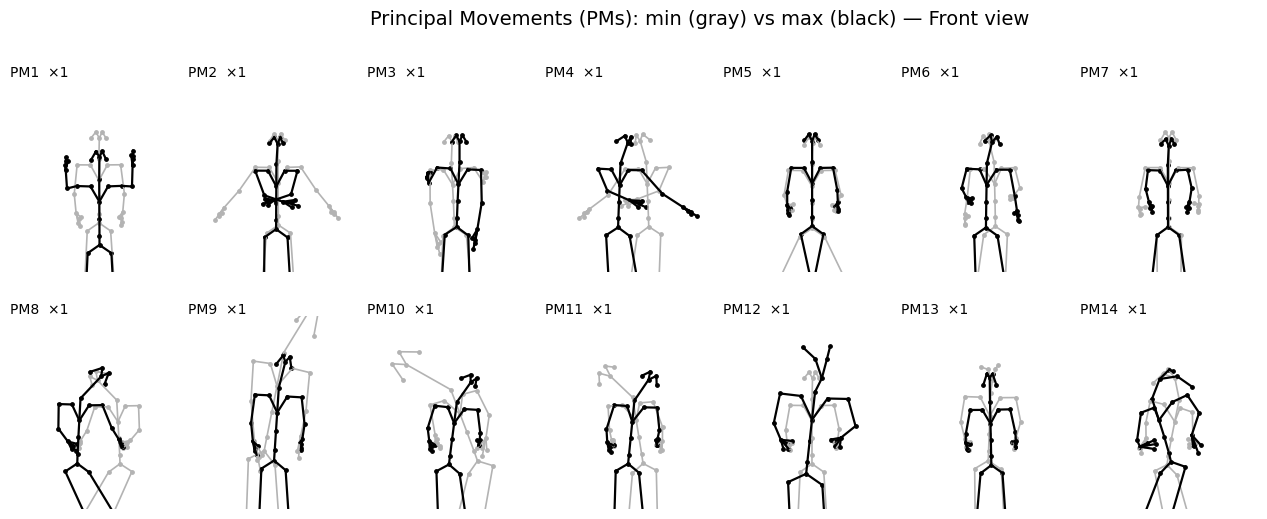

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def pose_from_pc(extreme_score, pc_idx, X_mean, pca, n_points):
    """Reconstruct 3D pose at given score along PC."""
    comp = pca.components_[pc_idx]              # shape: (n_points*3,)
    pose_vec = X_mean.ravel() + extreme_score * comp
    return pose_vec.reshape(n_points, 3)

def project(P, view="front"):
    """
    Project 3D (x,y,z) to 2D for plotting.
    front: (x, y)
    side : (z, y)  (sagittal)
    """
    if view == "front":
        return P[:, [0, 1]]
    elif view == "side":
        return P[:, [2, 1]]
    else:
        raise ValueError("view must be 'front' or 'side'")

def draw_skeleton(ax, P2, edges, color, lw=1.5, alpha=1.0):
    for i, j in edges:
        ax.plot([P2[i,0], P2[j,0]], [P2[i,1], P2[j,1]], color=color, lw=lw, alpha=alpha)
    ax.scatter(P2[:,0], P2[:,1], s=6, color=color, alpha=alpha)

def overlay_min_max(ax_front, ax_side, Pmin, Pmax, edges):
    Pf_min, Pf_max = project(Pmin,"front"), project(Pmax,"front")
    Ps_min, Ps_max = project(Pmin,"side"),  project(Pmax,"side")
    draw_skeleton(ax_front, Pf_min, edges, color="0.7", lw=1.2) # gray
    draw_skeleton(ax_front, Pf_max, edges, color="0.0", lw=1.6) # black
    draw_skeleton(ax_side,  Ps_min, edges, color="0.7", lw=1.2)
    draw_skeleton(ax_side,  Ps_max, edges, color="0.0", lw=1.6)
    # tidy
    for ax in (ax_front, ax_side):
        ax.set_aspect('equal')
        ax.axis('off')
# Collect global scores for each PC to find min/max
scores_all = np.vstack(pc_scores)      # shape: (sum_T, n_components)
pc_mins = scores_all.min(axis=0)
pc_maxs = scores_all.max(axis=0)

def rms_displacement(Pmin, Pmax):
    """RMS distance per joint across the posture pair."""
    D = np.linalg.norm(Pmax - Pmin, axis=1)   # per-joint 3D distance
    return np.sqrt((D**2).mean())

# Compute a per-PC amplification so the RMS shift hits a target
TARGET_RMS = 0.25  # tweak for visual clarity (units of your normalised coordinates)

amp_factors = []
for pc in range(pca.n_components_):
    # raw min/max poses (no amplification yet)
    Pmin_raw = pose_from_pc(pc_mins[pc], pc, X_mean, pca, n_points)
    Pmax_raw = pose_from_pc(pc_maxs[pc], pc, X_mean, pca, n_points)
    base_rms = rms_displacement(Pmin_raw, Pmax_raw)
    if base_rms <= 1e-12:
        amp = 1.0
    else:
        amp = TARGET_RMS / base_rms
    # quantize the label to nice steps (×1, ×1.5, ×2, ×3)
    if amp < 1.25:   label = "×1"
    elif amp < 1.75: label = "×1.5"
    elif amp < 2.5:  label = "×2"
    elif amp < 3.5:  label = "×3"
    else:            label = f"×{amp:.1f}"
    amp_factors.append((amp, label))

# --- helper: front-view overlay only ---
def overlay_min_max_front(ax, Pmin, Pmax, edges):
    Pf_min = Pmin[:, [0, 1]]
    Pf_max = Pmax[:, [0, 1]]
    draw_skeleton(ax, Pf_min, edges, color="0.7", lw=1.2)  # gray (min)
    draw_skeleton(ax, Pf_max, edges, color="0.0", lw=1.6)  # black (max)
    ax.set_aspect('equal')
    ax.axis('off')

# --- figure: 15 PCs in two rows (7 + 8) ---
N = min(15, pca.n_components_)
layout = [7, 8]   # first row = 7, second = 8
total_cols = max(layout)
nrows = len(layout)

fig = plt.figure(figsize=(total_cols * 2.3, nrows * 3.0))
fig.suptitle("Principal Movements (PMs): min (gray) vs max (black) — Front view", fontsize=14, y=0.97)

pc_idx = 0
for r, ncols in enumerate(layout):
    for c in range(ncols):
        if pc_idx >= N:
            break

        amp, amp_label = amp_factors[pc_idx]
        comp = pca.components_[pc_idx]
        mu = X_mean.ravel()
        Pmin = (mu + amp * pc_mins[pc_idx] * comp).reshape(n_points, 3)
        Pmax = (mu + amp * pc_maxs[pc_idx] * comp).reshape(n_points, 3)

        ax = plt.subplot2grid((nrows, total_cols), (r, c))
        overlay_min_max_front(ax, Pmin, Pmax, edges)
        ax.set_title(f"PM{pc_idx+1}  {amp_label}", fontsize=10, loc='left', pad=1)
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(-0.3, 1.0)

        pc_idx += 1

plt.subplots_adjust(wspace=0.0002, hspace=0.05)
#plt.subplots_adjust(wspace=0.05, hspace=0.15, top=0.9, bottom=0.02, left=0.02, right=0.98)
plt.savefig(OUT_DIR / "figure_PMs_minmax_front_compact.svg", dpi=300)
plt.show()



### Leader/Follower Comparisons

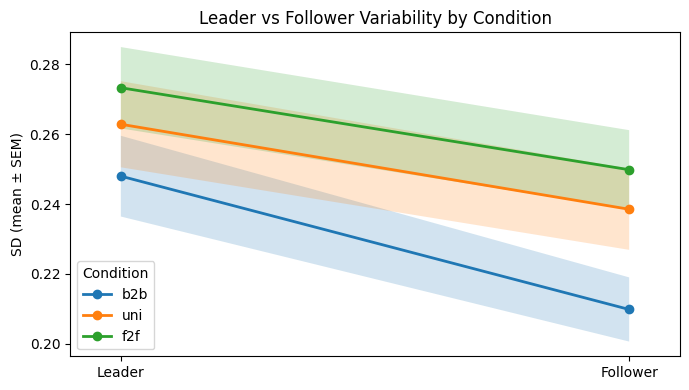

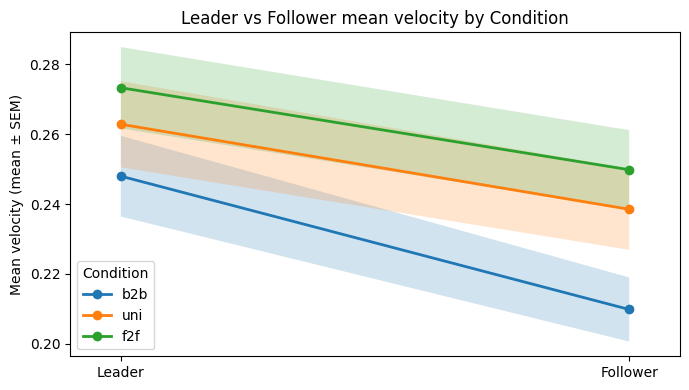

In [ ]:
from matplotlib import pyplot as plt   
import seaborn as sns

df_merged = pd.read_csv("CRQA_Stats_with_Conditions.csv")

# First, create Leader/Follower columns
df_merged['Leader_SD'] = df_merged.apply(
    lambda row: row['P1_SD'] if row['Leader'] == 'P1' else row['P2_SD'], 
    axis=1
)
df_merged['Follower_SD'] = df_merged.apply(
    lambda row: row['P2_SD'] if row['Leader'] == 'P1' else row['P1_SD'], 
    axis=1
)

# --- build leader/follower velocity columns from P1/P2 + Leader ---
df['leader_mean_velocity'] = df.apply(
    lambda r: r['P1_mean_velocity'] if r['Leader'] == 'P1' else r['P2_mean_velocity'], axis=1
)
df['follower_mean_velocity'] = df.apply(
    lambda r: r['P2_mean_velocity'] if r['Leader'] == 'P1' else r['P1_mean_velocity'], axis=1
)

# --- collapse to one row per (Condition, Pair) to avoid overweighting trials/PCs ---
pair_vel = (
    df.groupby(['Condition', 'Pair'], as_index=False)[['leader_mean_velocity','follower_mean_velocity']].mean()
)

# --- condition-level mean and SEM across pairs ---
cond_order = ['b2b', 'uni', 'f2f']
summary = (
    pair_vel.groupby('Condition')
    .agg(
        n=('Pair','nunique'),
        leader_mean=('leader_mean_velocity','mean'),
        follower_mean=('follower_mean_velocity','mean'),
        leader_sem =('leader_mean_velocity', lambda x: x.sem(ddof=1)),
        follower_sem=('follower_mean_velocity', lambda x: x.sem(ddof=1)),
    )
    .reindex(cond_order)
)


# Order conditions for consistent plotting
cond_order = ['b2b', 'uni', 'f2f']

# 1) Collapse to pair-level means (so each pair contributes once per condition)
pair_means = (
    df_merged
    .groupby(['Condition', 'Pair'], as_index=False)[['Leader_SD', 'Follower_SD']]
    .mean()
)

# 2) Compute condition-level mean and SEM across pairs
summary = (
    pair_means
    .groupby('Condition')
    .agg(
        n=('Pair', 'nunique'),
        leader_mean=('Leader_SD', 'mean'),
        follower_mean=('Follower_SD', 'mean'),
        leader_sem=('Leader_SD', lambda x: x.sem(ddof=1)),
        follower_sem=('Follower_SD', lambda x: x.sem(ddof=1)),
    )
    .reindex(cond_order)  # enforce plotting order
)

# 3) Plot: one line per condition (Leader -> Follower) with SEM shading
fig, ax = plt.subplots(figsize=(7, 4))
x = np.array([1, 2])  # 1 = Leader, 2 = Follower
ax.set_xticks(x)
ax.set_xticklabels(['Leader', 'Follower'])

for cond in summary.index:
    row = summary.loc[cond]
    y = np.array([row['leader_mean'], row['follower_mean']])
    y_sem = np.array([row['leader_sem'], row['follower_sem']])
    y_sem = np.nan_to_num(y_sem, nan=0.0)  # handle n=1 edge case

    ax.plot(x, y, marker='o', linewidth=2, label=cond)
    ax.fill_between(x, y - y_sem, y + y_sem, alpha=0.2)

ax.set_xlabel('')
ax.set_ylabel('SD (mean ± SEM)')
ax.set_title('Leader vs Follower Variability by Condition')
ax.legend(title='Condition')
ax.margins(x=0.1)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
x = np.array([1,2])
ax.set_xticks(x)
ax.set_xticklabels(['Leader','Follower'])

for cond in summary.index:
    row = summary.loc[cond]
    y = np.array([row['leader_mean'], row['follower_mean']])
    e = np.array([row['leader_sem'],  row['follower_sem']])
    e = np.nan_to_num(e, nan=0.0)  # handle n=1 edge cases

    ax.plot(x, y, marker='o', linewidth=2, label=cond)
    ax.fill_between(x, y - e, y + e, alpha=0.2)

ax.set_ylabel('Mean velocity (mean ± SEM)')
ax.set_title('Leader vs Follower mean velocity by Condition')
ax.legend(title='Condition')
ax.margins(x=0.1)
plt.tight_layout()
plt.show()

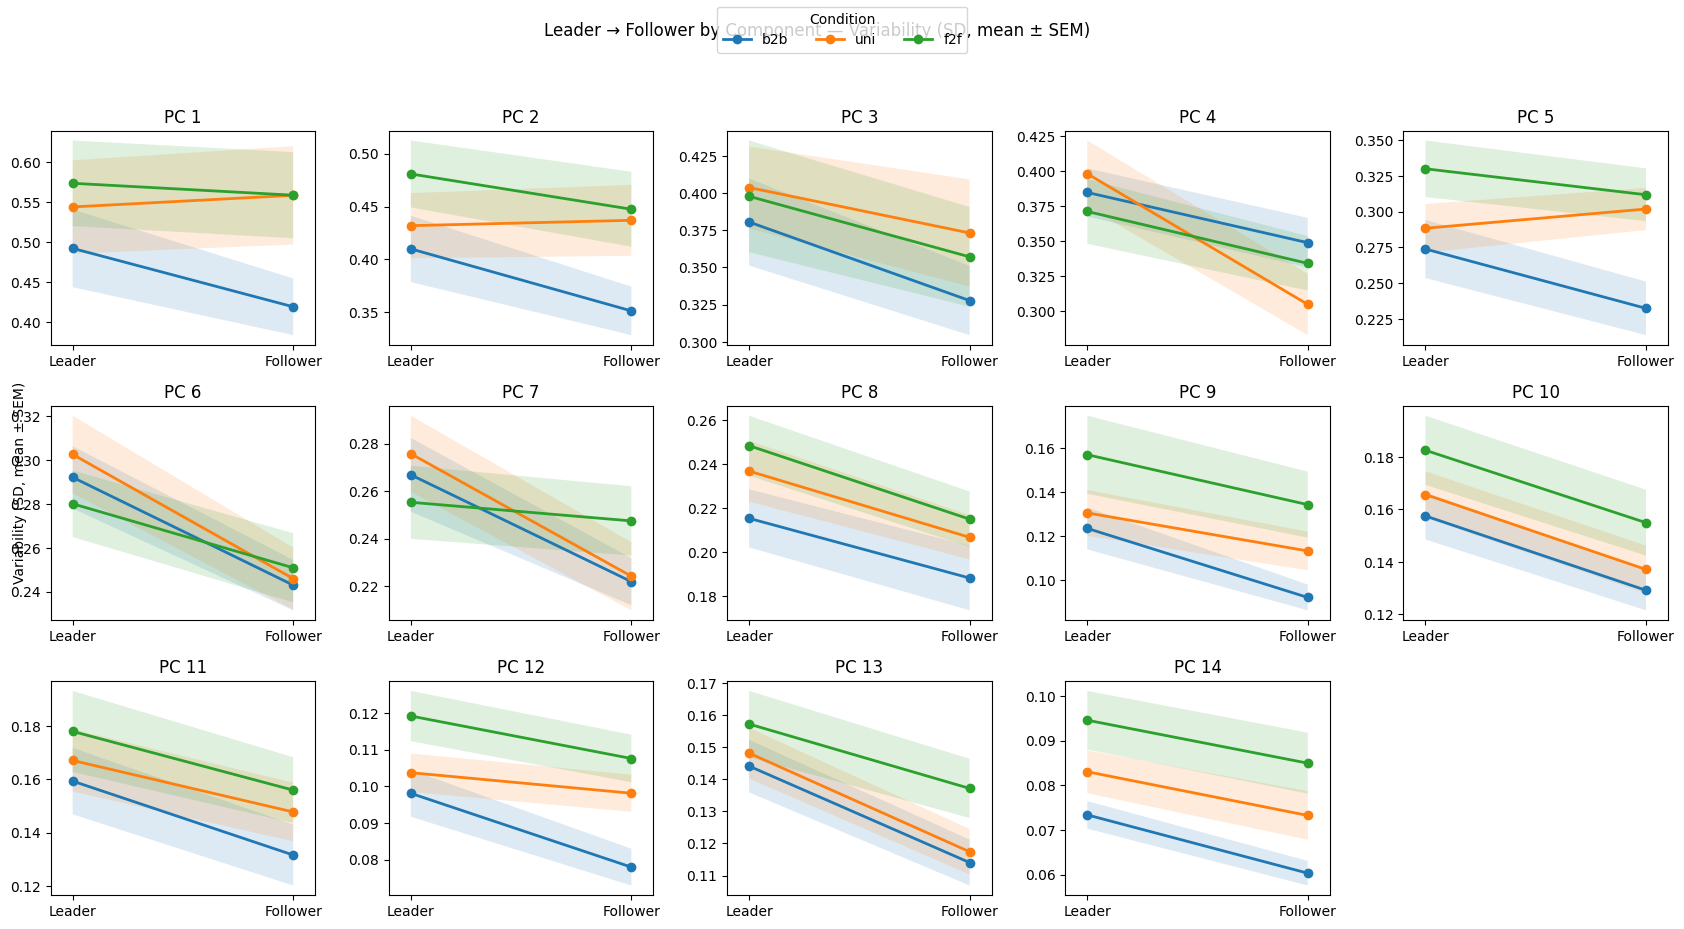

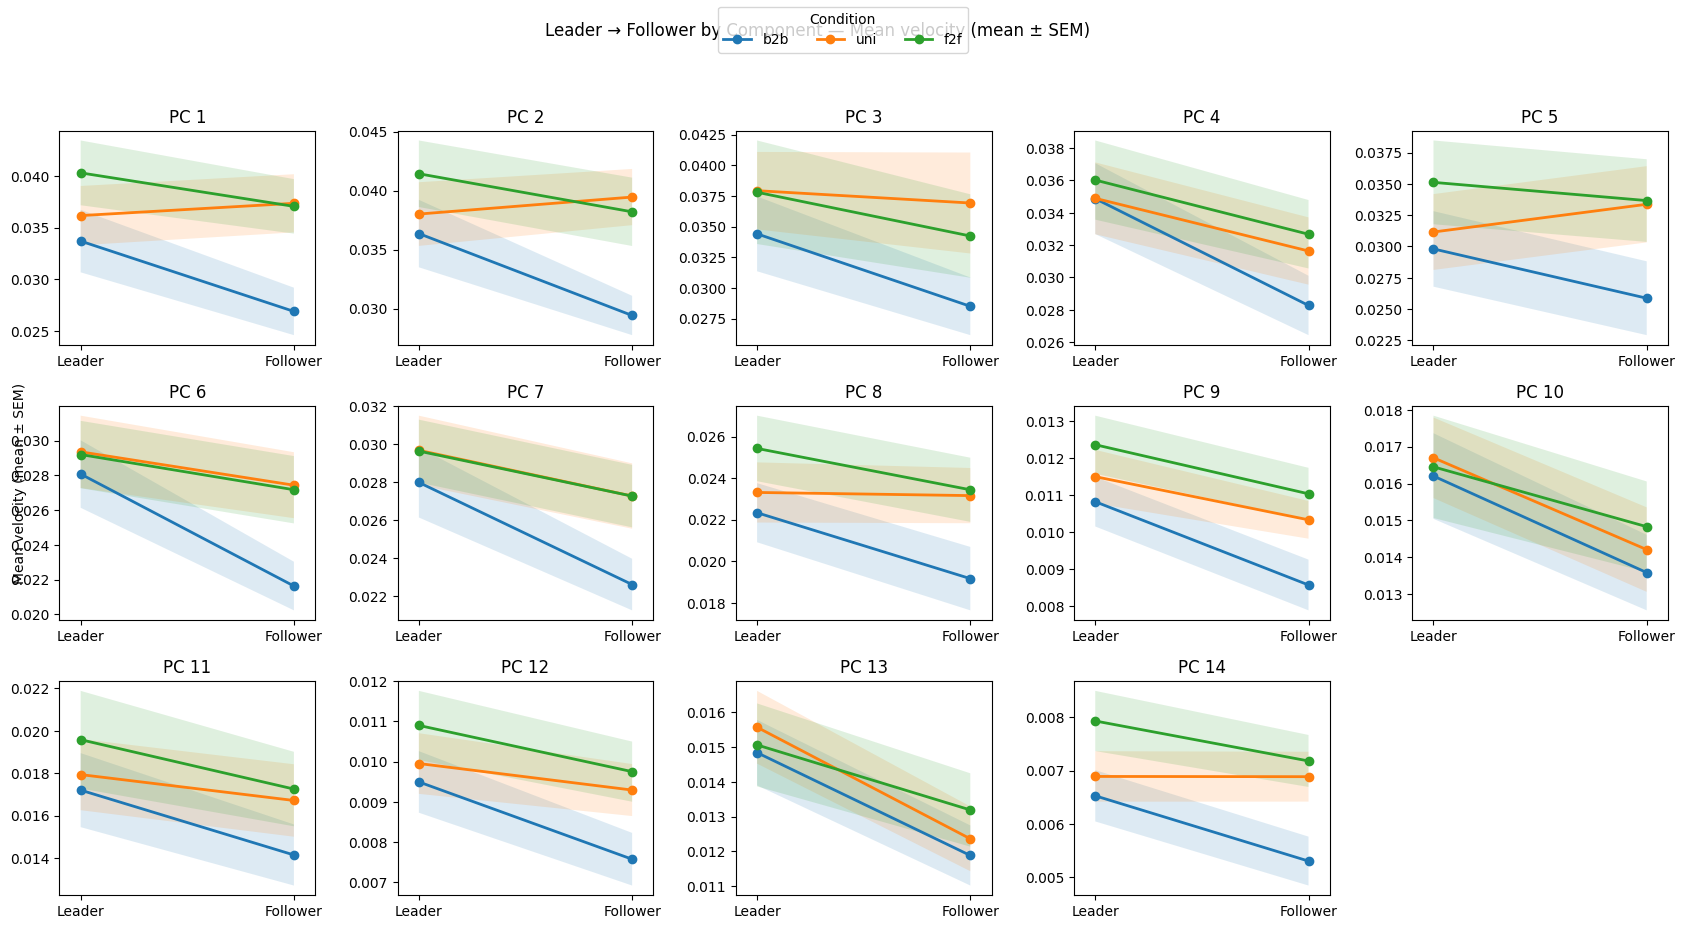

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# --- load ---
df = pd.read_csv("CRQA_Stats_with_Conditions.csv")

# --- Leader/Follower columns ---
df['Leader_SD']  = df.apply(lambda r: r['P1_SD'] if r['Leader']=='P1' else r['P2_SD'], axis=1)
df['Follower_SD']= df.apply(lambda r: r['P2_SD'] if r['Leader']=='P1' else r['P1_SD'], axis=1)
df['Leader_Vel'] = df.apply(lambda r: r['P1_mean_velocity'] if r['Leader']=='P1' else r['P2_mean_velocity'], axis=1)
df['Follower_Vel']=df.apply(lambda r: r['P2_mean_velocity'] if r['Leader']=='P1' else r['P1_mean_velocity'], axis=1)

cond_order = ['b2b','uni','f2f']
df = df[df['Condition'].isin(cond_order)]

# --- collapse within (Condition, PC, Pair) to avoid overweighting multiple trials ---
collapsed = (df.groupby(['Condition','PC','Pair'], as_index=False)
               .agg(Leader_SD=('Leader_SD','mean'),
                    Follower_SD=('Follower_SD','mean'),
                    Leader_Vel=('Leader_Vel','mean'),
                    Follower_Vel=('Follower_Vel','mean')))

# --- summary stats (mean ± SEM across pairs) ---
summary = (collapsed.groupby(['Condition','PC'])
           .agg(leader_SD_mean=('Leader_SD','mean'),
                follower_SD_mean=('Follower_SD','mean'),
                leader_SD_sem =('Leader_SD', lambda x: x.sem(ddof=1)),
                follower_SD_sem=('Follower_SD', lambda x: x.sem(ddof=1)),
                leader_Vel_mean=('Leader_Vel','mean'),
                follower_Vel_mean=('Follower_Vel','mean'),
                leader_Vel_sem =('Leader_Vel', lambda x: x.sem(ddof=1)),
                follower_Vel_sem=('Follower_Vel', lambda x: x.sem(ddof=1)))
           .reset_index())

pcs = sorted(summary['PC'].unique())
N = len(pcs)

def plot_grid(metric_label):
    # metric_label in {'SD','Vel'}
    means_leader   = f'leader_{metric_label}_mean'
    means_follower = f'follower_{metric_label}_mean'
    sem_leader     = f'leader_{metric_label}_sem'
    sem_follower   = f'follower_{metric_label}_sem'

    # layout
    cols = min(5, N)
    rows = math.ceil(N/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.2*rows), squeeze=False)
    x = np.array([1,2])

    for i, pc in enumerate(pcs):
        r, c = divmod(i, cols)
        ax = axes[r, c]

        for cond in cond_order:
            sub = summary[(summary['PC']==pc) & (summary['Condition']==cond)]
            if sub.empty:
                continue
            y  = np.array([sub[means_leader].values[0], sub[means_follower].values[0]])
            se = np.array([sub[sem_leader].values[0],   sub[sem_follower].values[0]])
            se = np.nan_to_num(se, nan=0.0)

            ax.plot(x, y, marker='o', linewidth=2, label=cond)
            ax.fill_between(x, y-se, y+se, alpha=0.15)

        ax.set_xticks(x); ax.set_xticklabels(['Leader','Follower'])
        ax.set_title(f'PC {pc}')
        ax.margins(x=0.1)

    # remove any empty axes
    for j in range(N, rows*cols):
        r, c = divmod(j, cols)
        fig.delaxes(axes[r, c])

    ylabel = 'Variability (SD, mean ± SEM)' if metric_label=='SD' \
             else 'Mean velocity (mean ± SEM)'
    fig.text(0.04, 0.5, ylabel, va='center', rotation='vertical')
    handles, labels = axes[0,0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title='Condition', loc='upper center', ncol=3)
    fig.suptitle(f'Leader → Follower by Component — {ylabel}', y=0.98)
    fig.tight_layout(rect=[0.03, 0.03, 1, 0.94])
    plt.show()

# --- Figure 1: variability per PC ---
plot_grid('SD')

# --- Figure 2: mean velocity per PC ---
plot_grid('Vel')
